# Student Identification & Submission Details

Please complete the following information before submitting your notebook.

**UNI:**  kz2594
**Full Name:**  Kaihang Zhou.
**Public GitHub Repository URL (Final Project Report & Code):**

**UNI:**  soo2117
**Full Name:**  Stanley Omondi
**Public GitHub Repository URL (Final Project Report & Code):**

**UNI:**  AS7429
**Full Name:**  Adeline Setiawan
**Public GitHub Repository URL (Final Project Report & Code):** halfabluebanana

---

https://github.com/halfabluebanana/advanced_projects_machine_learning_QMSSGR5074.git

## Submission Requirements

- The GitHub repository **must be public**.
- The repository should include:
  - A complete and well-formatted final report
  - Clean, well-documented source code
  - Clear instructions for reproducing results (if applicable)
- Verify that all links are functional and accessible prior to submission.

# Project Submission Guidelines

### Submission Due Date: March 9, 2026

Throughout this notebook, you will encounter the keyword **`TODO`** in multiple sections. Each `TODO` indicates a required component that must be completed by you.

These may include:

- Implementing missing code
- Specifying or tuning model parameters
- Writing explanations and technical reasoning
- Performing analysis and interpreting results
- Justifying modeling decisions
- Completing evaluation procedures

---

## Expectations

You are expected to:

- Replace **every** `TODO` with correct, fully functional code.
- Provide complete, clear, and technically sound explanations where required.
- Justify modeling choices using appropriate reasoning and evidence.
- Ensure the notebook executes from start to finish **without errors**.

> **Note:** Any section that still contains `TODO` at the time of submission will be considered **incomplete**.

# World Happiness Classification Competition

## Project Objectives

This competition is designed to help you:

- Develop a deep understanding of how machine learning models function
- Understand the role and impact of model hyperparameters
- Learn from systematic experimentation and model iteration
- Produce a professional, well-structured notebook report
- Publish the final project as a portfolio-ready GitHub repository

---

## Project Workflow

You will complete the project through the following stages:

1. **Load and Merge Datasets**  
   - Import all relevant datasets  
   - Perform necessary joins and validation  

2. **Data Preprocessing**  
   - Build preprocessing pipelines using `sklearn`'s `ColumnTransformer`  
   - Handle missing values, encoding, scaling, and feature engineering  

3. **Model Training**  
   - Fit the model using the processed data  
   - Save both the preprocessing pipeline and trained model  

4. **Prediction and Evaluation**  
   - Generate predictions  
   - Evaluate performance using appropriate metrics  

5. **Hyperparameter Tuning**  
   - Systematically tune model parameters  
   - Compare performance across configurations  

6. **Deep Learning Experimentation**  
   - Implement and evaluate a neural network approach  
   - Compare results with classical ML models  

7. **Model Explainability (SHAP)**  
   - Apply SHAP for feature importance analysis  
   - Interpret and explain model decisions  

8. **Final Report Submission**  
   - Clean and organize the notebook  
   - Ensure full reproducibility  
   - Upload the final report and code to a public GitHub repository  

---

## 0. Loading Datasets

In this section, we load the **World Happiness 2023** datasets that will be used throughout the project.

**Objectives of this stage:**

- Import the datasets into the notebook environment
- Inspect their structure and contents
- Verify column names and data types
- Identify potential inconsistencies before merging

> Careful dataset inspection at this stage prevents downstream errors and ensures a clean modeling pipeline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv('/content/drive/MyDrive/WHR_2023.csv')

# Inspect the first few rows to understand the structure
whr_df


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394
...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027


In [ ]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes
y_test_labels = y_test.astype('category').cat.codes

### Conceptual Question

In the next cell, briefly explain the following:

1. What does `y_train.astype('category').cat.codes` do?
2. What is the difference between `y_train_labels` and `y_train`?

Keep your explanation clear and concise.

*1. What does y_train.astype('category').cat.codes do?*

**Answer:** It converts a series of categorical values to integer codes starting with 0, where each unique category gets a unique value. The conversion happens in two steps where the first, converts to categorical dtype and builds an internal lookup table and secondly the _cat.codes_ step that extracts the integer codes as a new series.  

*2. What is the difference between __y_train_labels_ and _y_train_?

**Answer:** _y_train_ refers to the original categorical human readable labels produced by the train_test_split exactly as they were created by our pd.qcut function ie: 'Very Low', 'Low', etc while the _y_train_labels_ are the integer coded values derived from the _'y_train.astype('category').cat.codes'_ function which is the machine readable version of the same information.

### Add New Data

In [ ]:
# Truncated and cleaned up region data to merge
countrydata=pd.read_csv("/content/drive/MyDrive/newcountryvars.csv")

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [ ]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.

# for our use case, we used the left join to do the merging, this is because we do not lose any of our original data. furthermore,
# countries missing from the country data just get missing values for new features introduced at merge. we deduplicate to remove the redundant
# columns introduced by the merge,

X_train = X_train.merge(countrydata,
                        left_on='country',
                        right_on='country_name',
                        how='left')

X_test = X_test.merge(countrydata,
                      left_on='country',
                      right_on='country_name',
                      how='left')

DUPLICATE_COLS = [
    'country_name',
    'region_y',
    'gdp_per_capita_y',
    'social_support_y',
    'healthy_life_expectancy_y',
    'freedom_to_make_life_choices_y',
    'generosity_y',
    'perceptions_of_corruption_y',
    'happiness_score_y',
    'happiness_category_y',
]

X_train = X_train.drop(columns=[c for c in DUPLICATE_COLS if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in DUPLICATE_COLS if c in X_test.columns])

RENAME_MAP = {
    'region_x':                       'region',
    'gdp_per_capita_x':               'gdp_per_capita',
    'social_support_x':               'social_support',
    'healthy_life_expectancy_x':      'healthy_life_expectancy',
    'freedom_to_make_life_choices_x': 'freedom_to_make_life_choices',
    'generosity_x':                   'generosity',
    'perceptions_of_corruption_x':    'perceptions_of_corruption',
    'happiness_score_x':              'happiness_score',
    'happiness_category_x':           'happiness_category',
}

X_train = X_train.rename(columns={k: v for k, v in RENAME_MAP.items()
                                   if k in X_train.columns})
X_test  = X_test.rename(columns={k: v for k, v in RENAME_MAP.items()
                                   if k in X_test.columns})

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)



X_train shape: (95, 15)
X_test  shape: (42, 15)


In [ ]:
X_train.head(150)

,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,Madagascar,Sub-Saharan Africa,0.632,0.779,0.178,0.187,0.177,0.134,2.557090e+07,70.7,0.512149,65.515,10.346140,6.145955,1319.699397
1,Mauritania,Sub-Saharan Africa,1.099,0.764,0.244,0.320,0.130,0.195,4.420184e+06,31.0,0.513106,63.239,8.463790,4.266000,3527.264154
2,Mongolia,East Asia,1.379,1.494,0.244,0.425,0.239,0.058,3.075647e+06,21.6,0.734832,69.806,14.845520,9.750000,10449.207270
3,Tajikistan,Commonwealth of Independent States,0.972,1.248,0.291,0.599,0.104,0.292,8.921343e+06,31.5,0.627472,69.582,11.261860,10.355820,2600.585607
4,Ukraine,Central and Eastern Europe,1.358,1.354,0.355,0.551,0.265,0.016,4.422295e+07,24.1,0.743049,71.129,15.306720,11.340000,7361.011228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,South Korea,East Asia,1.853,1.188,0.603,0.446,0.112,0.163,5.098221e+07,12.5,0.900992,82.128,16.587520,12.179211,34540.649270
91,Ethiopia,Sub-Saharan Africa,0.793,1.114,0.250,0.451,0.283,0.101,1.049574e+08,29.6,0.447750,64.602,8.351520,2.580780,1522.954782
92,China,East Asia,1.510,1.249,0.468,0.666,0.115,0.145,1.409517e+09,3.3,0.737681,75.963,13.535750,7.641840,13345.477460
93,Peru,Latin America and Caribbean,1.390,1.153,0.499,0.549,0.073,0.027,3.216548e+07,22.7,0.739749,74.814,13.386340,9.013470,11294.840330


---

## 1. Exploratory Data Analysis and Visualization (EDAV)

In [ ]:
print(X_train.dtypes)

country                           object
region                            object
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


### Describe What You Observe

*Replace this section with your response.*

**Answer:**
- After the merge operation, we get a clearer view and understanding of the given countries across more features. This is evidenced by the increase of the number of columns for the countries from 8 as seen before the merge to 15 columns. We further get better understanding of the countries and regions, especially because after the merge we see the regions column introduced which enhances our understanding of the data beyond the country level.

- Happiness_score and happiness_category are excluded since they're the target variable. Inclusion would cause data leakage.

- clean merge with no _x/_y suffix columns. This confirms the clean up worked

- country and region columns are strings and need encoding. (e.g. one-hot or label encoding) before feeding into ML model.

- some float64 columns may need scaling (e.g. features such as gdp_per_capita and generosity) are on different scales. We may need to normalise or standardise.



### Missing Values Analysis

Compute the number and percentage of missing values for each column and present the results in a clear summary table.

In [ ]:
# Your code here: TODO
# update - consider merged, we have tons of missing values for the newcountrys
missing = X_train.isnull().sum()
missing_percent = 100 * missing / len(X_train)
missing_table = pd.concat([missing, missing_percent], axis=1)
missing_table

print(missing_percent)
# print(missing_table)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)
print("Missing Values Summary Train Set:")
display(missing_df[missing_df['Missing Values'] > 0])

missing_test = X_test.isnull().sum()
missing_percent_test = 100 * missing_test / len(X_test)
missing_table = pd.concat([missing_test, missing_percent_test], axis=1)
missing_table
#print(missing_percent_test)
missing_df2 = pd.DataFrame({
    'Missing Values': missing_test,
    'Percentage (%)': missing_percent_test
}).sort_values(by='Missing Values', ascending=False)
print("Missing Values Summary Test Set:")
display(missing_df2[missing_df2['Missing Values'] > 0])

country                           0.000000
region                            0.000000
gdp_per_capita                    0.000000
social_support                    0.000000
healthy_life_expectancy           0.000000
freedom_to_make_life_choices      0.000000
generosity                        0.000000
perceptions_of_corruption         0.000000
population                        6.315789
population_below_poverty_line    16.842105
hdi                               6.315789
life_expectancy                   7.368421
expected_years_of_schooling       7.368421
mean_years_of_schooling           7.368421
gni                               7.368421
dtype: float64
Missing Values Summary Train Set:


,Missing Values,Percentage (%)
population_below_poverty_line,16,16.842105
mean_years_of_schooling,7,7.368421
expected_years_of_schooling,7,7.368421
life_expectancy,7,7.368421
gni,7,7.368421
population,6,6.315789
hdi,6,6.315789


Missing Values Summary Test Set:


,Missing Values,Percentage (%)
gni,3,7.142857
expected_years_of_schooling,3,7.142857
mean_years_of_schooling,3,7.142857
life_expectancy,3,7.142857
hdi,3,7.142857
population_below_poverty_line,3,7.142857
population,3,7.142857
healthy_life_expectancy,1,2.380952


### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.

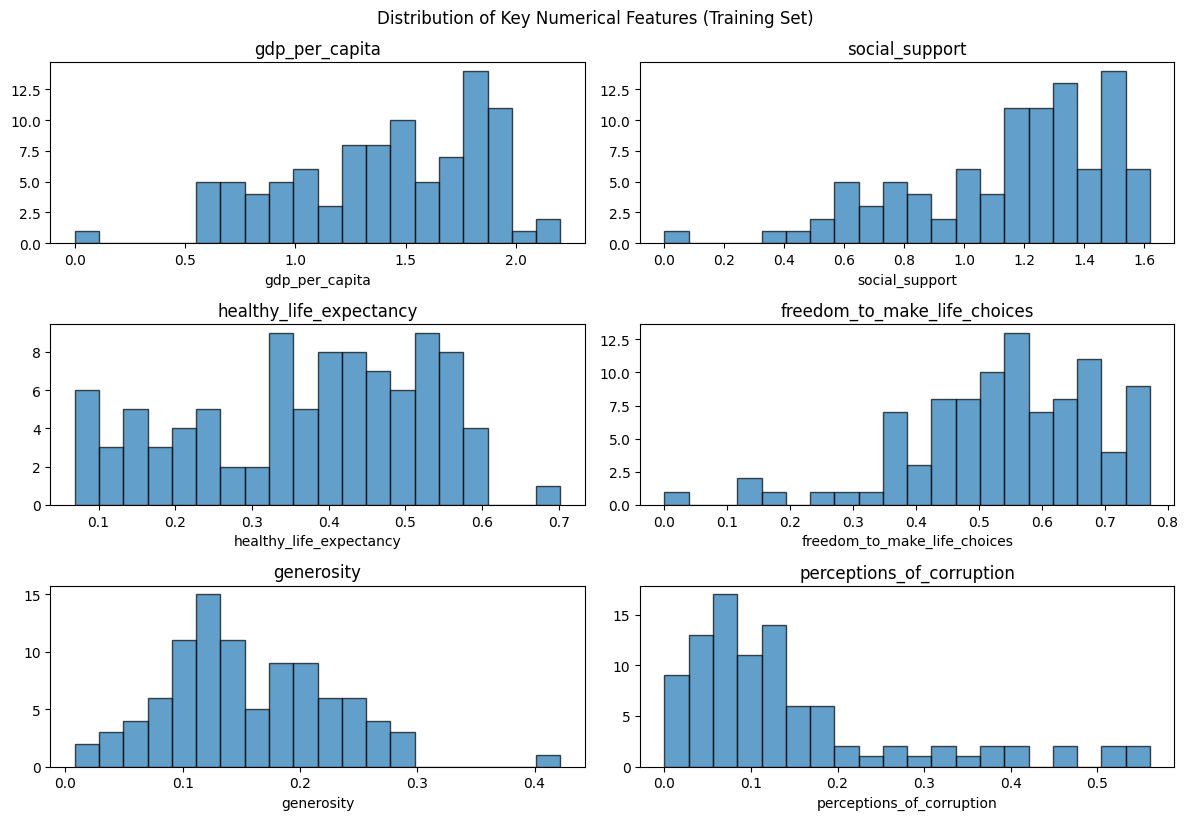

In [ ]:
# Your plotting code here: TODO
# key numerical values ---gdp_per_capita	social_support	healthy_life_expectancy
# freedom_to_make_life_choices	generosity	perceptions_of_corruption
#population_x, population_y	population_below_poverty_line_y	hdi_y	life_expectancy_y
# going with features that influence the levels of happiness

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
key_features = [c for c in num_cols if c in [
    'gdp_per_capita',
    'social_support',
    'healthy_life_expectancy',
    'freedom_to_make_life_choices',
    'generosity',
    'perceptions_of_corruption'
]][:6]

if not key_features:
    key_features = num_cols[:6]

# Histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    if i < len(axes):
        axes[i].hist(X_train[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
plt.tight_layout()
plt.suptitle('Distribution of Key Numerical Features (Training Set)', y=1.02)
plt.show()



**Features chosen:**
gdp_per_capita, social_support, healthy_life_expectancy, freedom_to_make_life_choices, generosity, perceptions_of_corruption.

**Comment on notable patterns, skewness and outliers:**
- From the distributions, we notice that the data for the countries shows a most of the left-skewed pattern begins with a decent distribution from earlier one with a few extreme outliers which form a very clear distinction. This is especially clear when viewing the graphs for the gdp_per_capita, social_support and freedom_to_make_life_choices. This seems to indicate that most of the countries share the same characteristics, but at different levels compared to each other.
---
- **Skewness:** GDP per capita and other economic/development variables are typically right-skewed (long upper tail): many countries at lower values, fewer at high values. Bounded indicators (e.g. social support, freedom, perceptions of corruption, often on 0–1 scales) may show left skew (mass near the high end) or mild right skew.

- Most skewed: social_support (left skewed), freedom_to_make_life_choices (left skewed), and perceptions_of_corruption (right skewed) are the most skewed. Suggests that transformations may help linear models

- gdp_per_capita's bimodal distribution (peaks around 1.0 and 1.7).  No extreme outliers but a wide  spread. Suggests two groups of countries (developing vs developed). May be a strong class separator

- generosity is the most symmetrically / normally distributed and has the
  narrowest range (0.10 - 0.15), with one high outlier (near 0.45).

- social_support has heavy left-skew and concentration (1.2–1.6), with one outlier near 0. Suggests most countries report strong social support, with a few struggling nations pulling the left tail.

- healthy_life_expectancy is roughly ultimodal, peaks around
  0.45–0.50, with notable cluster at 0.05–0.10. Suggesting low life
  expectancy countries. Wide spread with a slight right skew.

- freedom_to_make_life_choices — Left-skewed, concentrated
  between 0.4–0.8. A sparse low-value tail (0.0–0.2). Most
  countries cluster toward higher freedom scores.

- - **Outliers:** A small number of countries often sit at the extremes (e.g. very high GDP or very low generosity/corruption). These can affect means and some models; robust scaling or winsorization may help if they dominate.


### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

(0.0, 27.0)

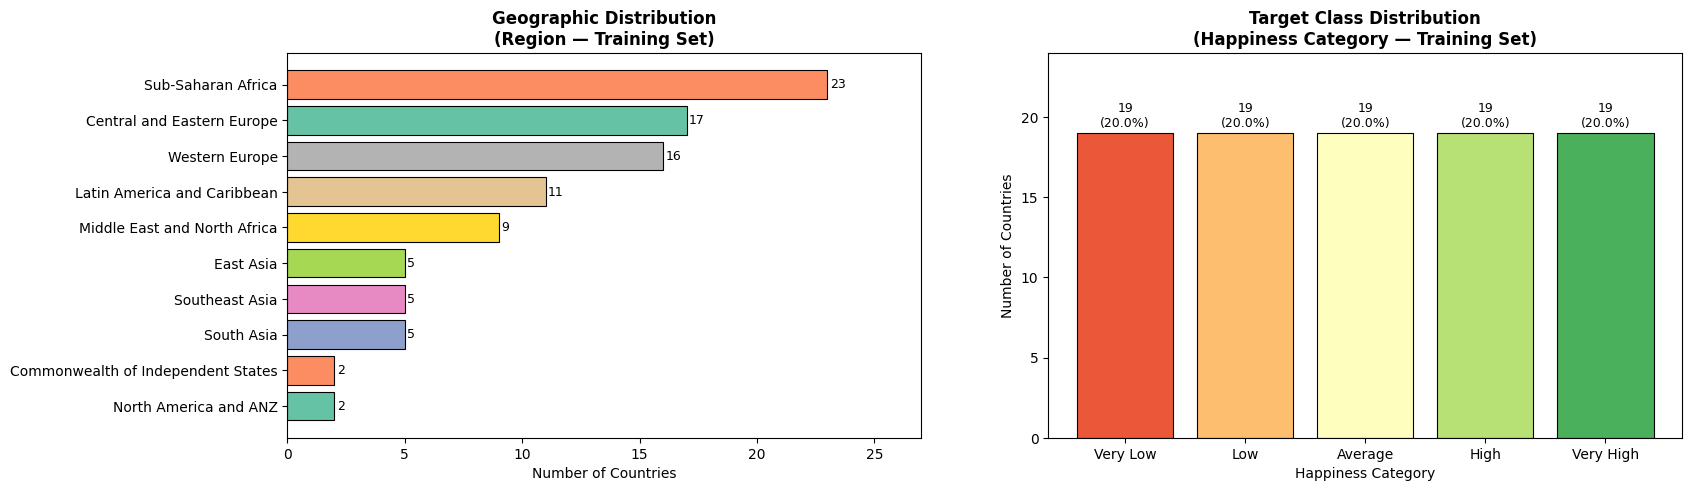

In [ ]:
# Your plotting code(s) here: TODO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
category_order = ['Very Low', 'Low', 'Average', 'High', 'Very High']
label_counts   = y_train.value_counts().reindex(category_order, fill_value=0)
total          = label_counts.sum()
bars = axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=sns.color_palette('RdYlGn', len(category_order)),
    edgecolor='black',
    linewidth=0.8,
)

for bar, count in zip(bars, label_counts.values):
   pct = 100 * count / total
   axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9,
    )

axes[1].set_title('Target Class Distribution\n(Happiness Category — Training Set)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Happiness Category', fontsize=10)
axes[1].set_ylabel('Number of Countries', fontsize=10)
axes[1].set_ylim(0, label_counts.max() + 5)


region_counts = X_train['region'].value_counts().sort_values(ascending=True)

axes[0].barh(
    region_counts.index,
    region_counts.values,
    color=sns.color_palette('Set2', len(region_counts)),
    edgecolor='black',
    linewidth=0.8,
)

# Annotate with count so exact numbers are readable without gridlines
for idx, count in enumerate(region_counts.values):
    axes[0].text(count + 0.1, idx, str(count), va='center', fontsize=9)

axes[0].set_title('Geographic Distribution\n(Region — Training Set)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Countries', fontsize=10)
axes[0].set_xlim(0, region_counts.max() + 4)



### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

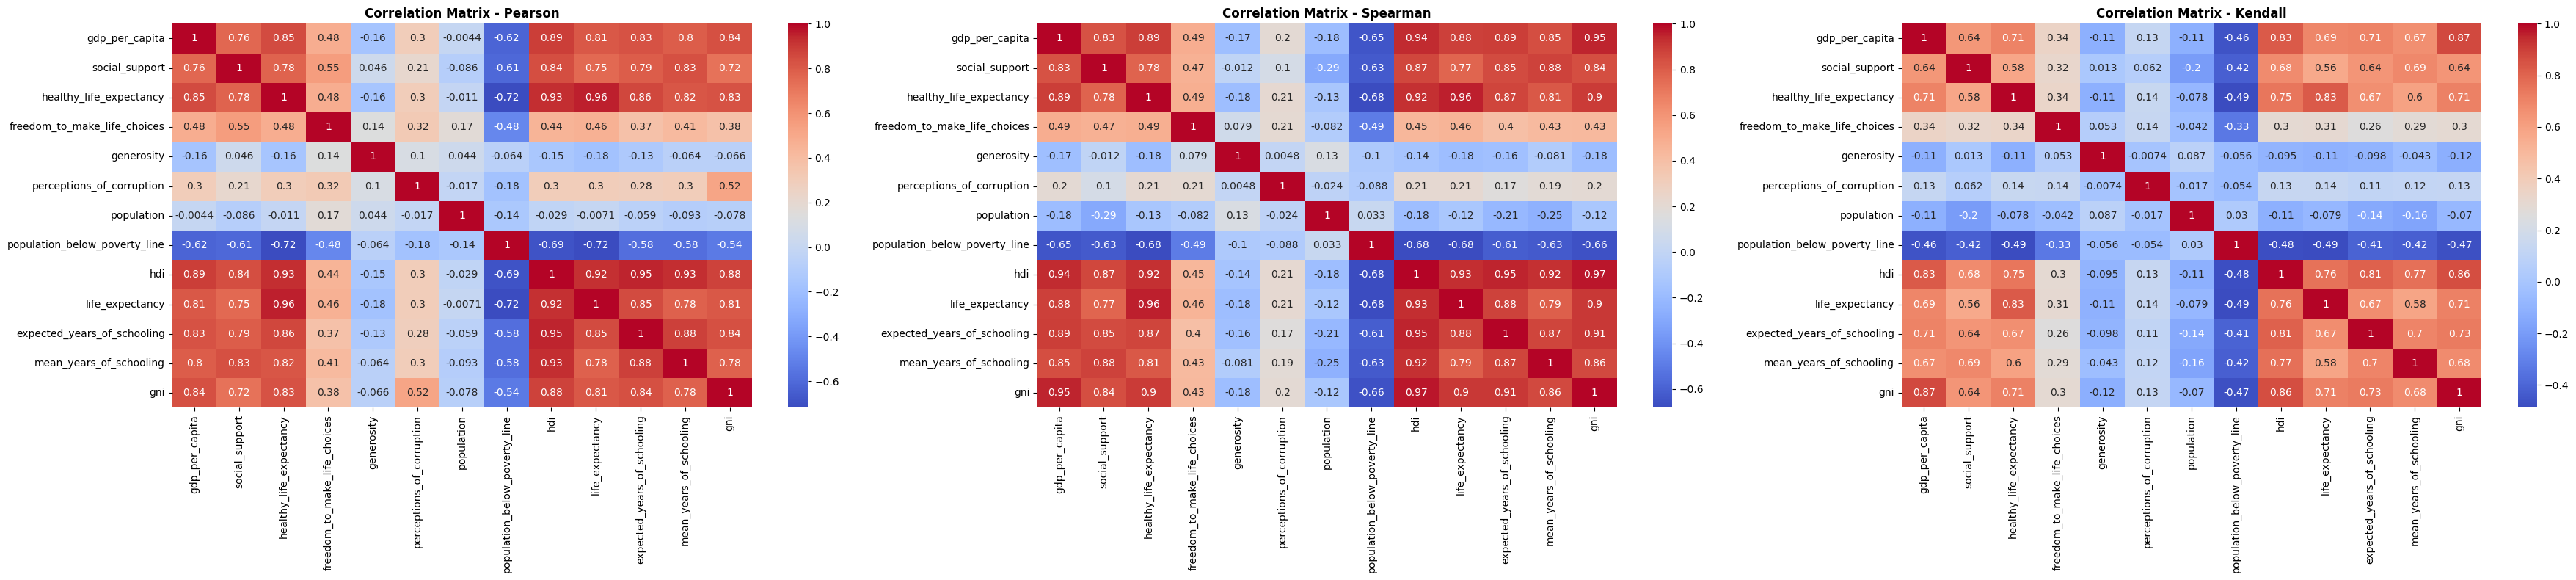

Top 10 Spearman correlations (excluding self-correlations):
hdi                          gni                            0.972306
gni                          hdi                            0.972306
life_expectancy              healthy_life_expectancy        0.958141
healthy_life_expectancy      life_expectancy                0.958141
expected_years_of_schooling  hdi                            0.953793
hdi                          expected_years_of_schooling    0.953793
gdp_per_capita               gni                            0.953552
gni                          gdp_per_capita                 0.953552
hdi                          gdp_per_capita                 0.940337
gdp_per_capita               hdi                            0.940337


In [ ]:
# Your code here: TODO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_df = X_train[num_cols].dropna()

pearson_correlation = num_df.corr(method='pearson')
spearman_correlation = num_df.corr(method='spearman')
kendall_correlation = num_df.corr(method='kendall')

fig, axes = plt.subplots(1, 3, figsize=(36, 8))

for i, corr_df in enumerate([pearson_correlation, spearman_correlation, kendall_correlation]):
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', ax=axes[i])
    axes[i].set_title(f'Correlation Matrix - {["Pearson", "Spearman", "Kendall"][i]}', fontsize=
                      12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top correlations (Spearman — most reliable for this dataset since most features are skewed)
print("Top 10 Spearman correlations (excluding self-correlations):")
spearman_pairs = (
    spearman_correlation.where(~np.eye(len(spearman_correlation), dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print(spearman_pairs.head(10).to_string())


###Brief interpretations of correlations and collinearity

From the histograms earlier, we note that most features are skewed (gdp_per_capita, perceptions_of_corruption, generosity are all right-skewed).
  
Pearson assumes i) variables are normally distributed, ii) relationship is strictly linear. Neither is true here.

Spearman converts values to ranks first, neutralising skews and outliers. This makes making it robust for this dataset especially with n = 95.

Kendall also uses ranks but is conservative and suited to small samples with many ties.

---

###Interpretation from heatmaps

Strong positive correlations (all three methods agree, as evident from the dark red):
  - hdi strong correlation (~0.8–0.95) with life_expectancy, mean_years_of_schooling, expected_years_of_schooling

  - gdp_per_capita correlates with healthy_life_expectancy, hdi, gni. Sugggest wealthier countries have better health and development outcomes
  - healthy_life_expectancy correlates with life_expectancy. near-duplicate features

Weak/negative correlations:
  - generosity correlates with most other features. But near-zero correlations throughout, suggesting its independence
  - perceptions_of_corruption shows inconsistent correlations behaves differently across the three methods, suggesting a non-monotonic or noisy relationship


### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

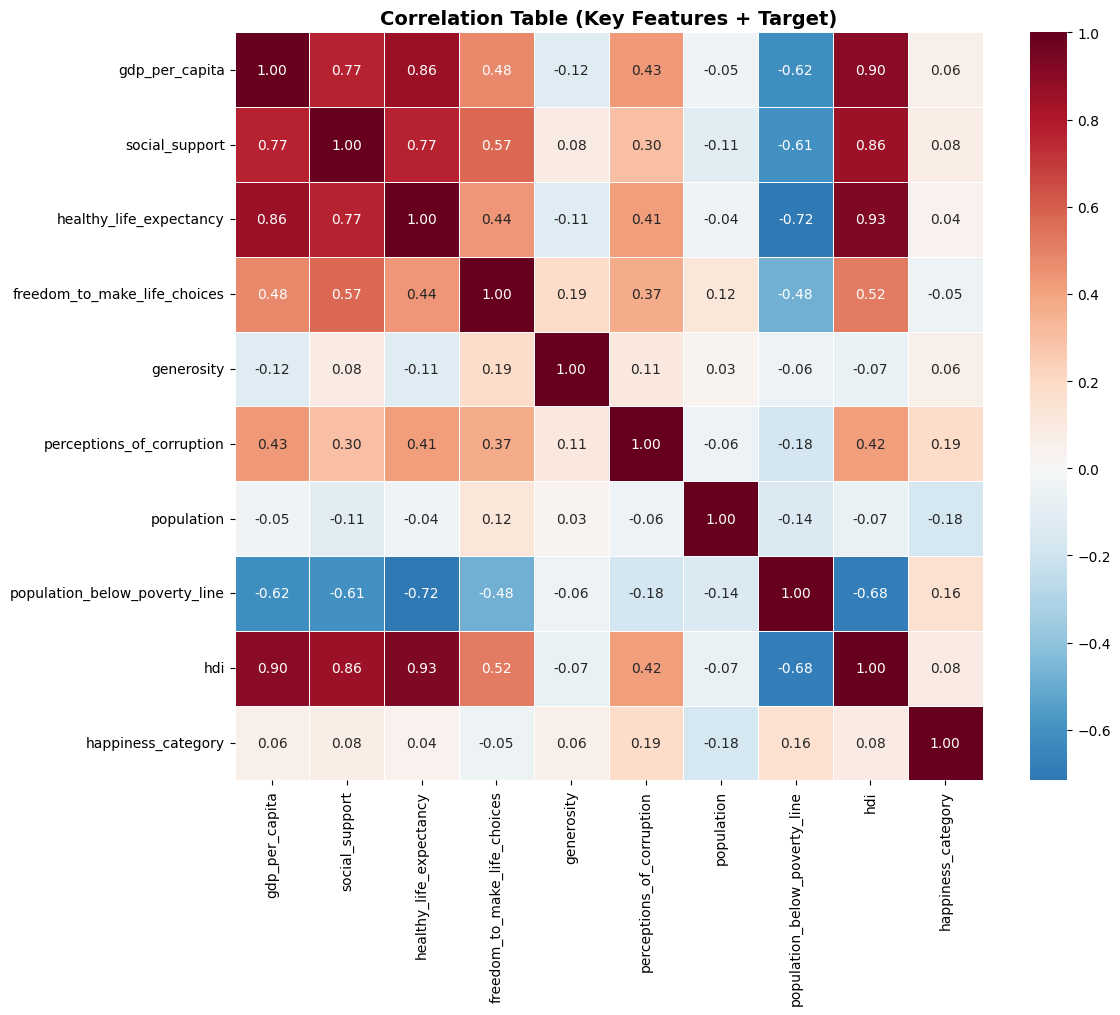

Correlation with target (happiness_category):
perceptions_of_corruption        0.189
population_below_poverty_line    0.160
hdi                              0.083
social_support                   0.078
gdp_per_capita                   0.059
generosity                       0.058
healthy_life_expectancy          0.043
freedom_to_make_life_choices    -0.046
population                      -0.180


/tmp/ipykernel_19057/2757820991.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
/tmp/ipykernel_19057/2757820991.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
/tmp/ipykernel_19057/2757820991.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
/tmp/ipykernel_19057/2757820

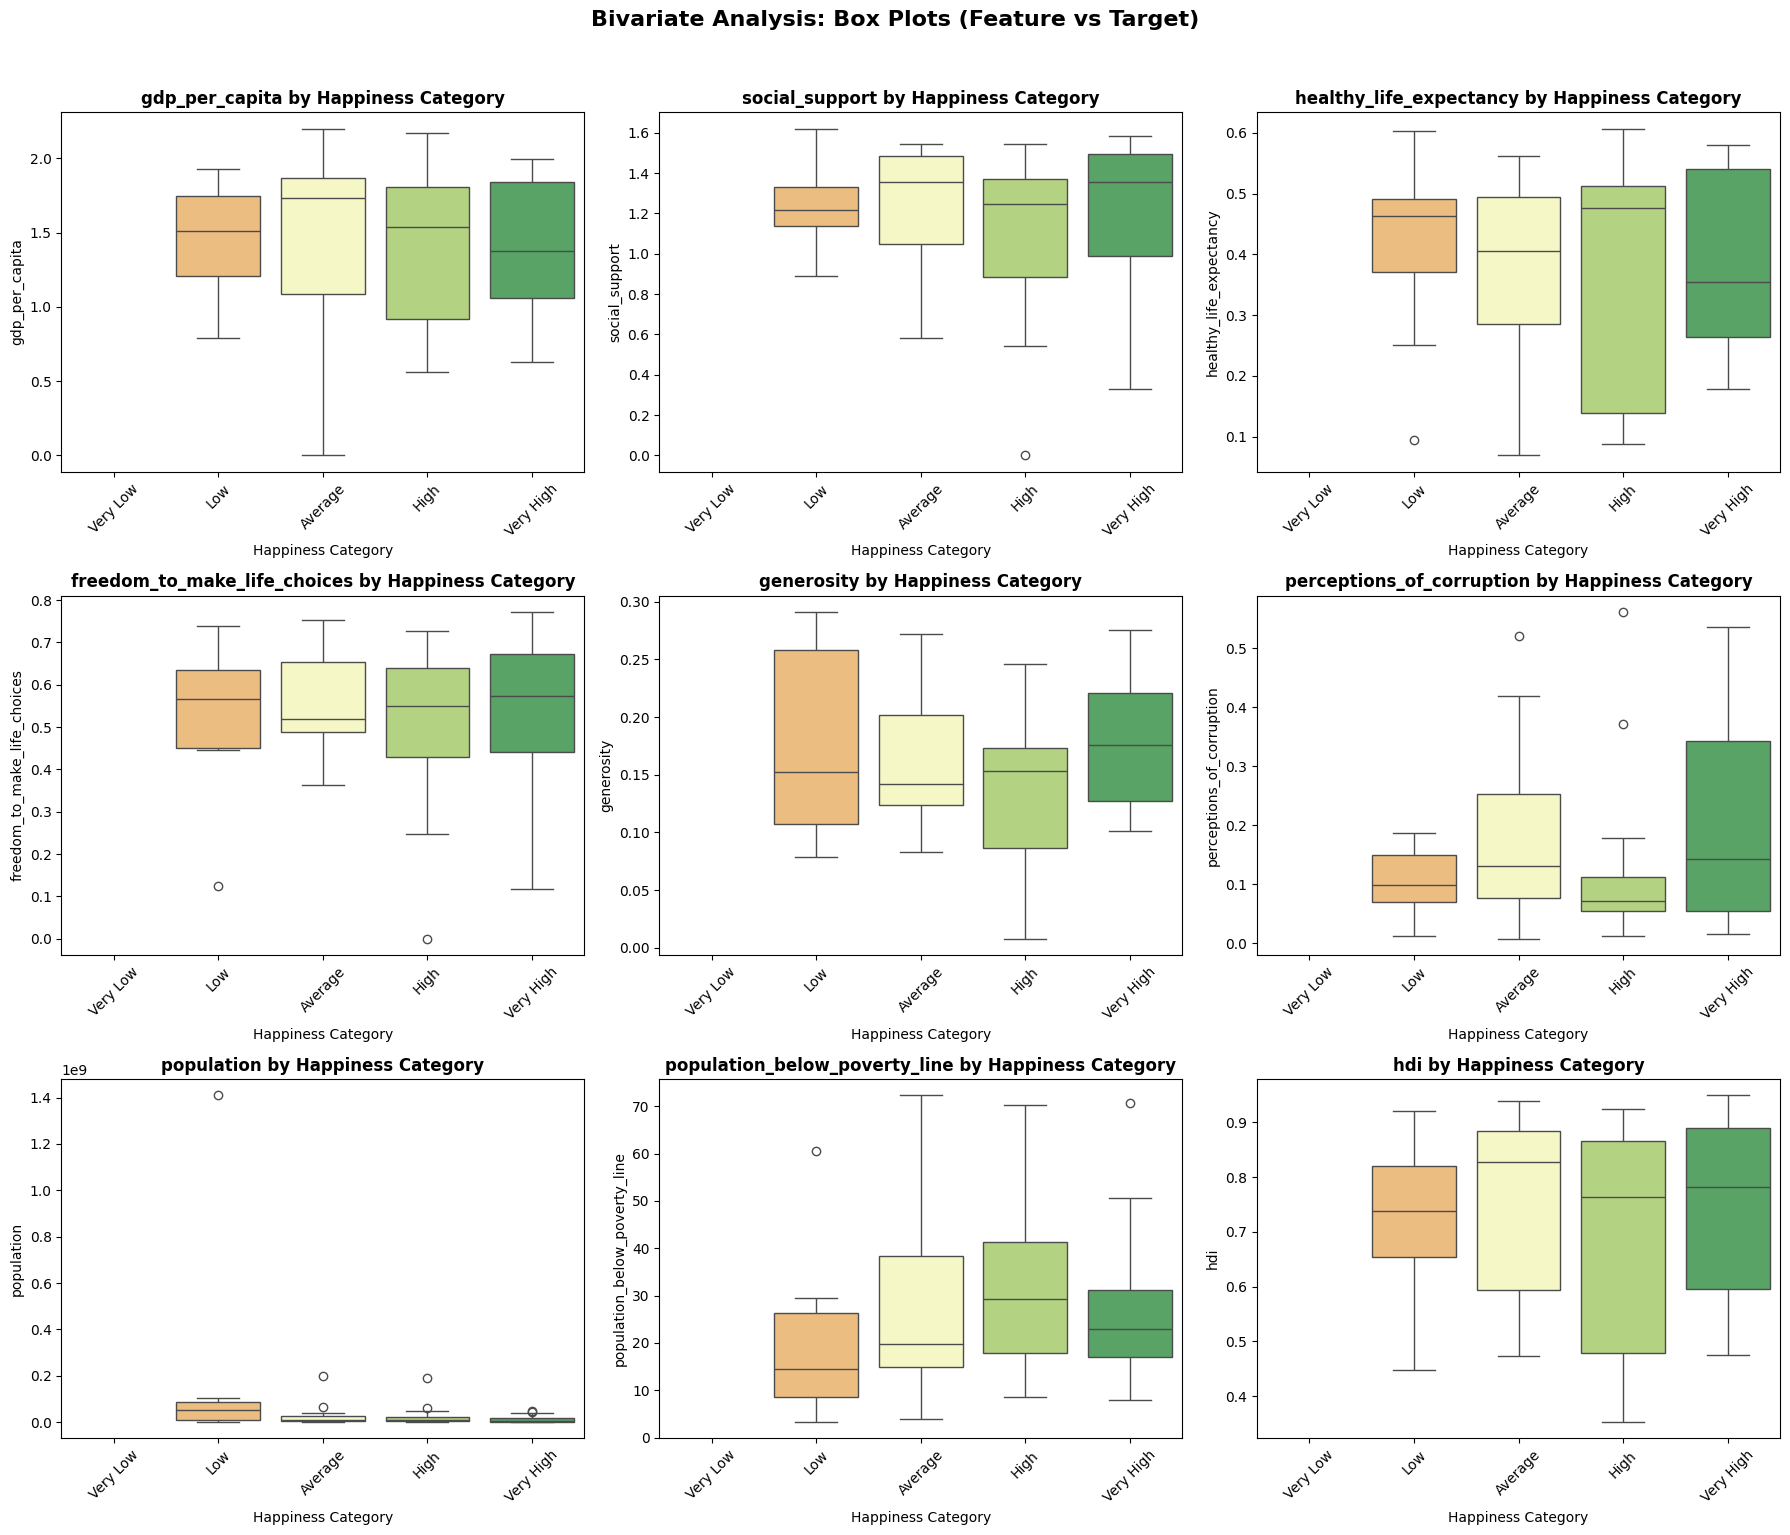

/tmp/ipykernel_19057/2757820991.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
/tmp/ipykernel_19057/2757820991.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
/tmp/ipykernel_19057/2757820991.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same eff

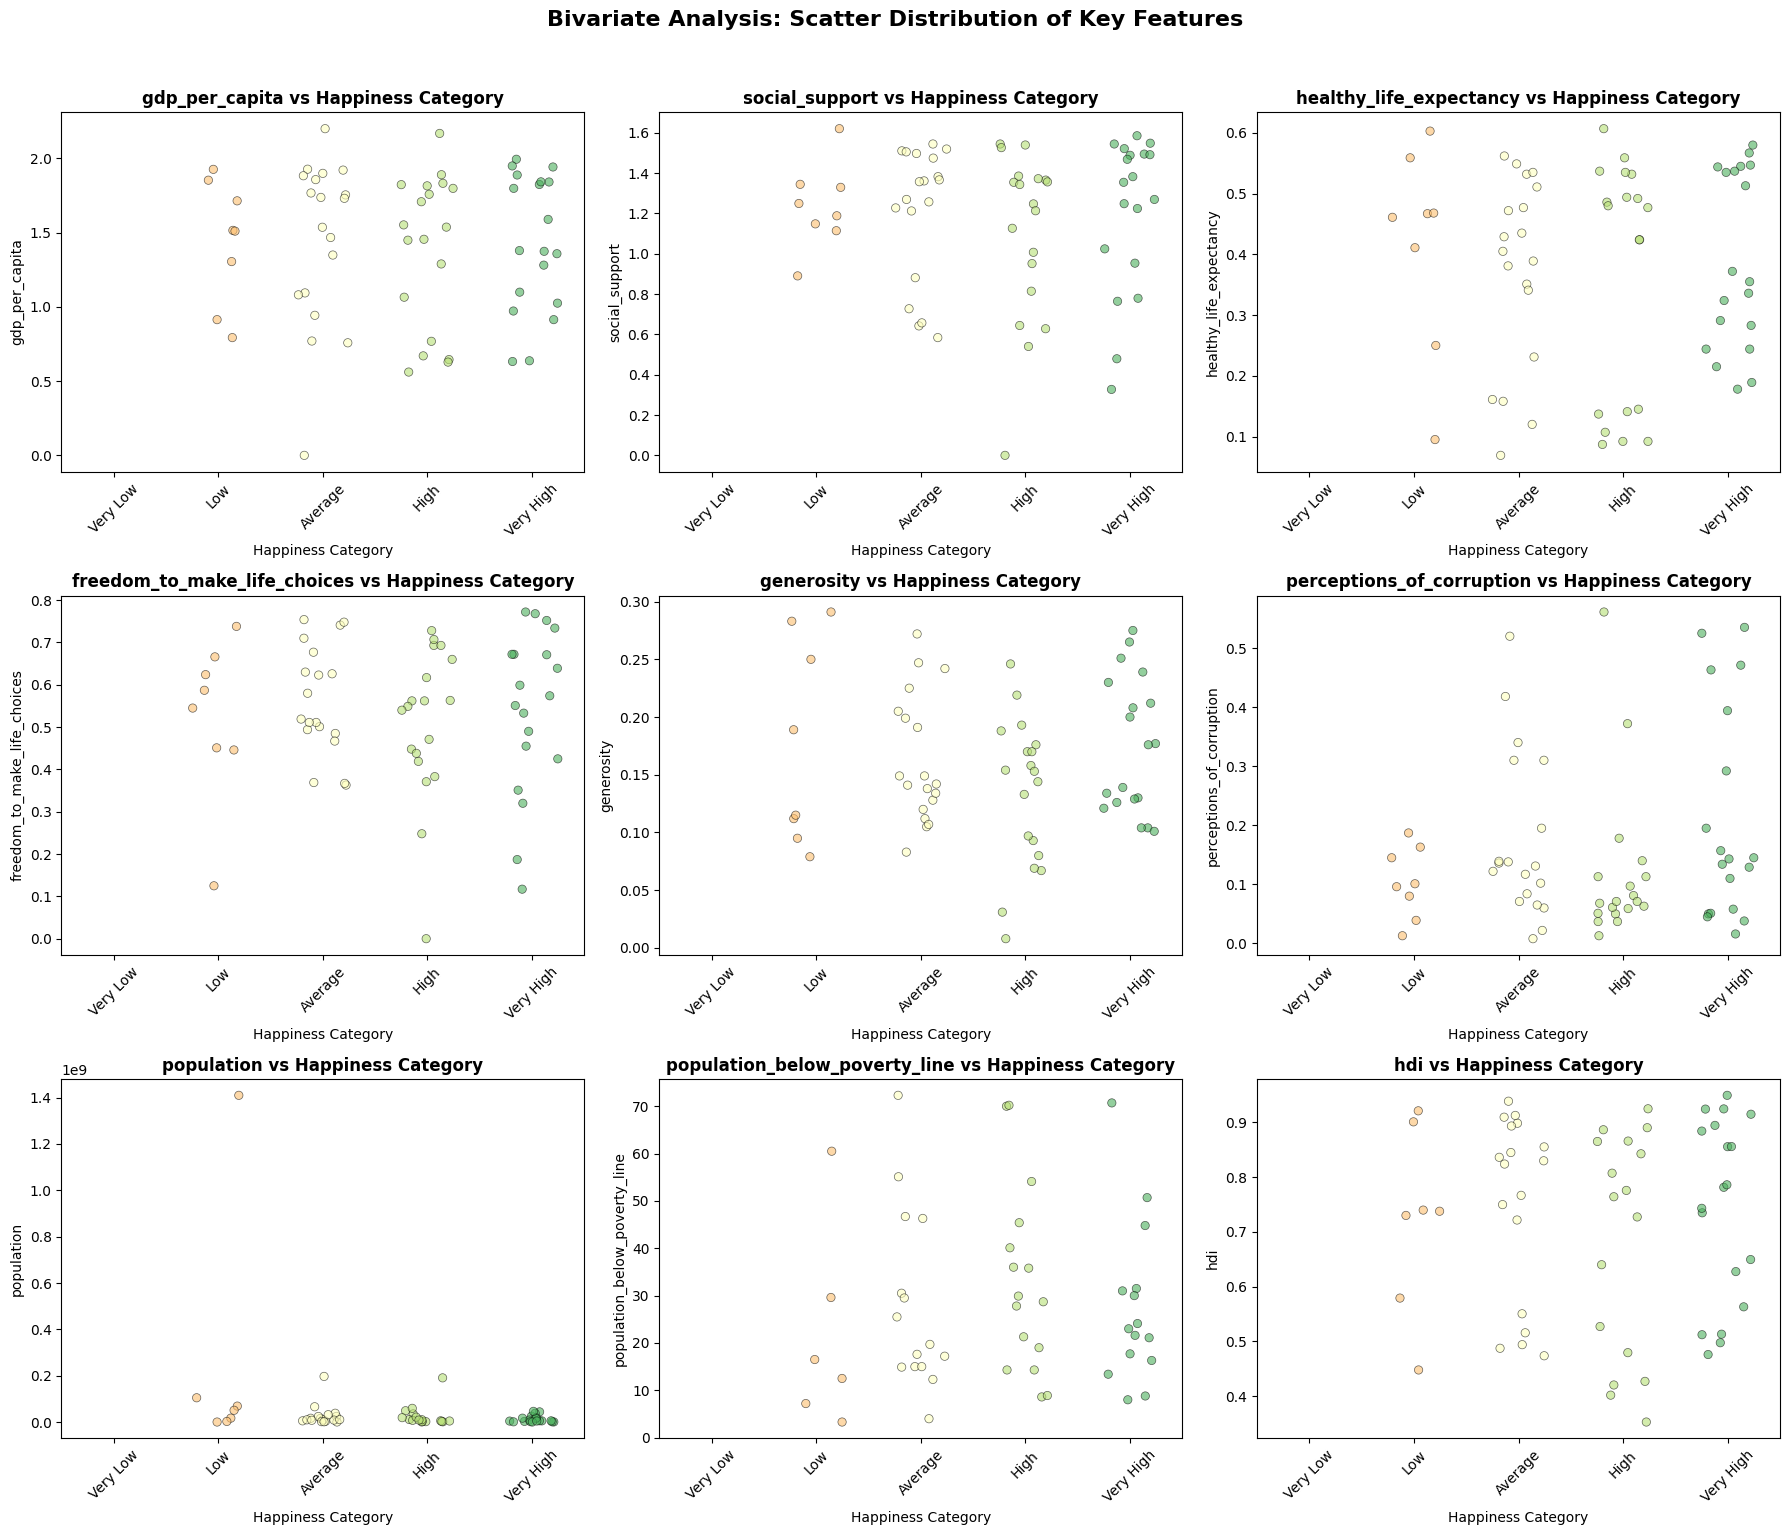

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


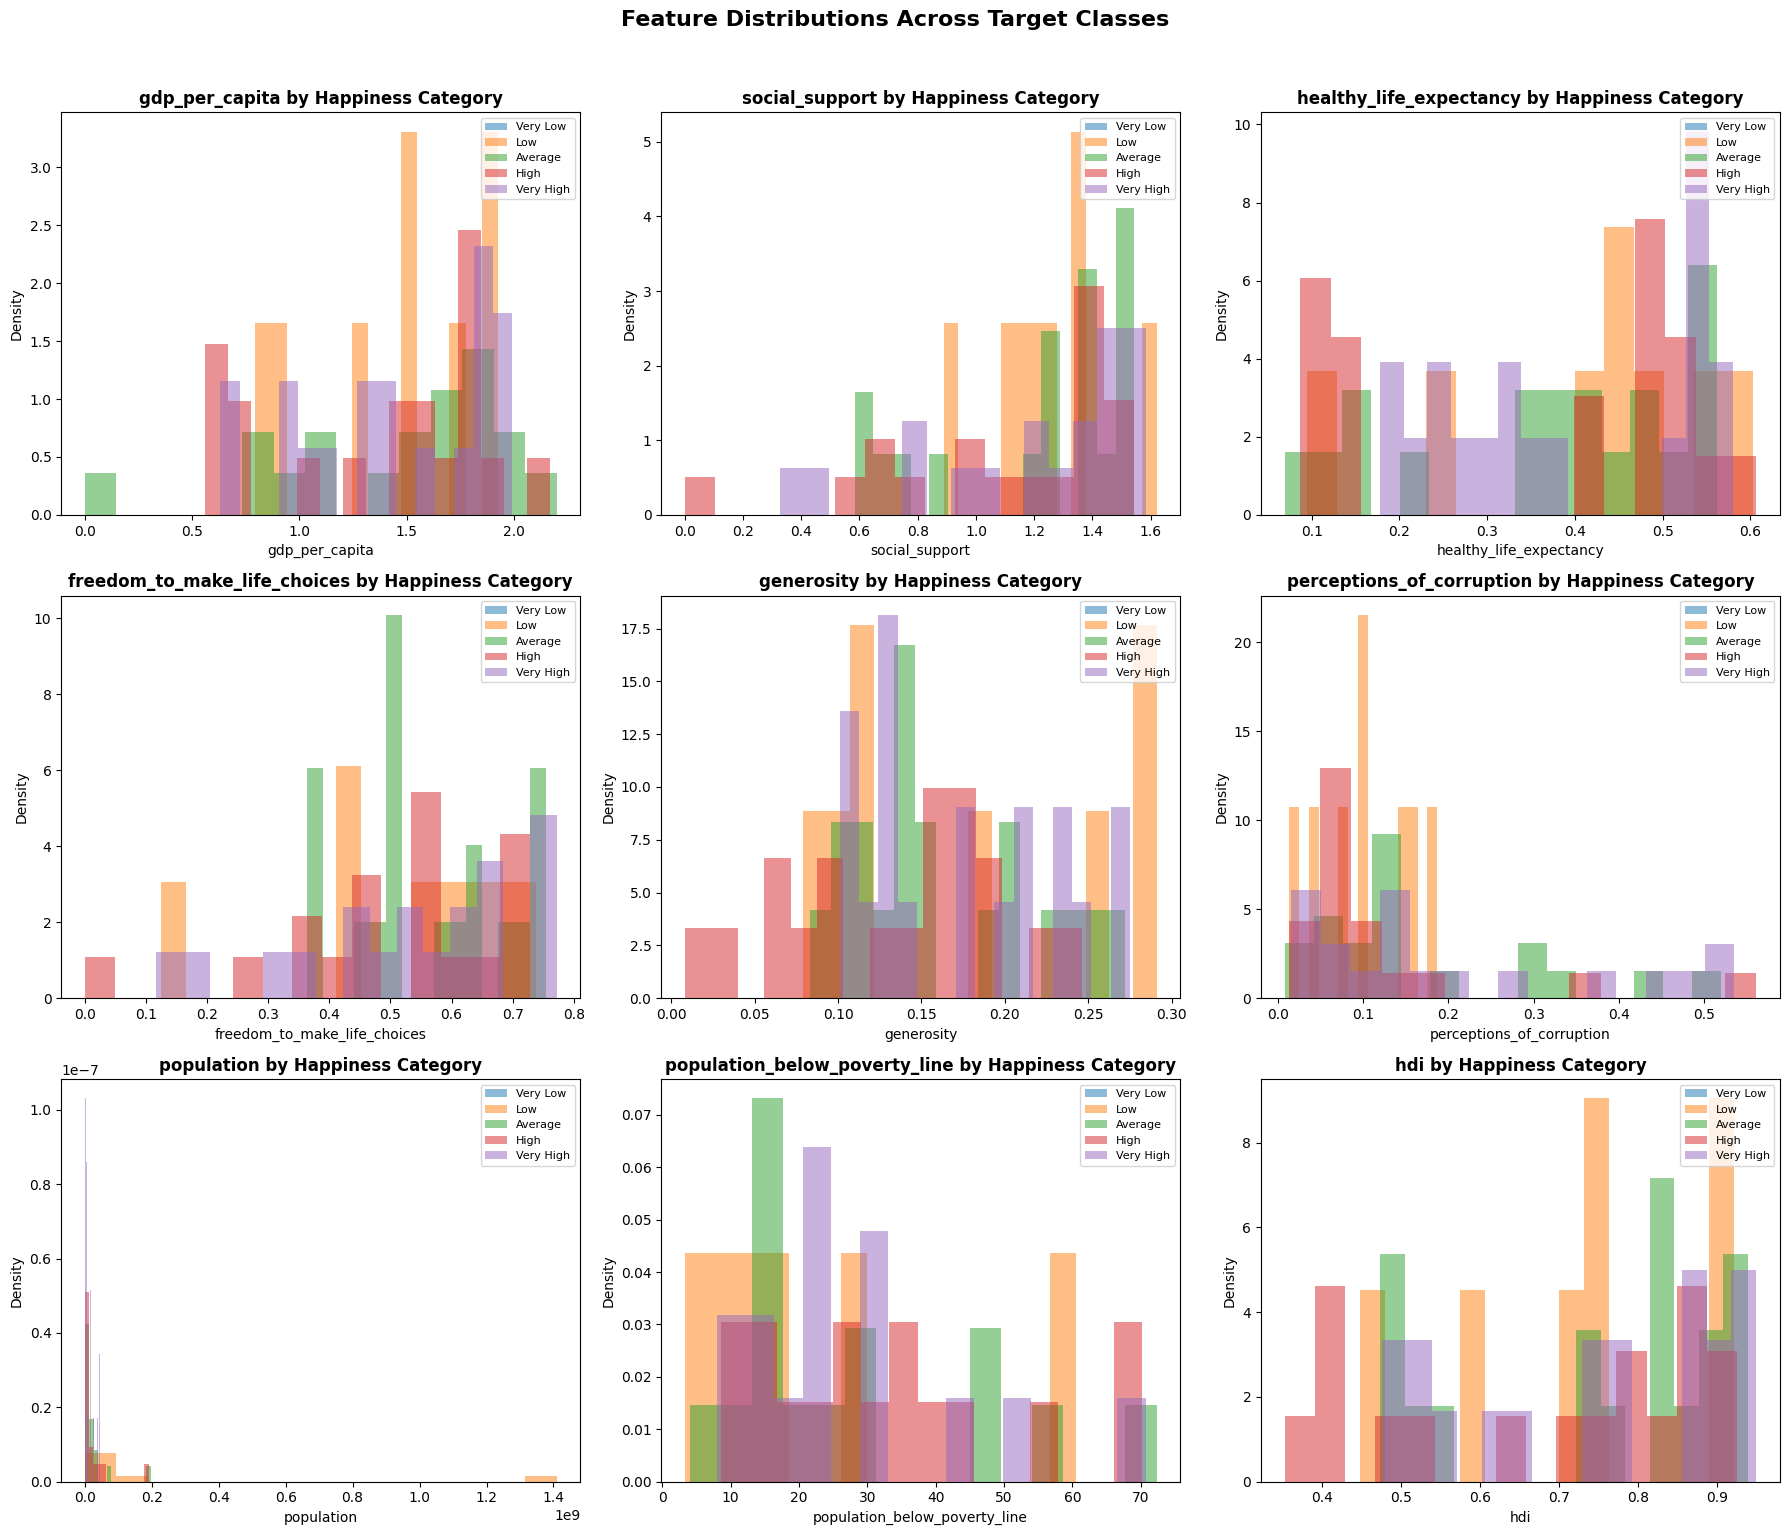

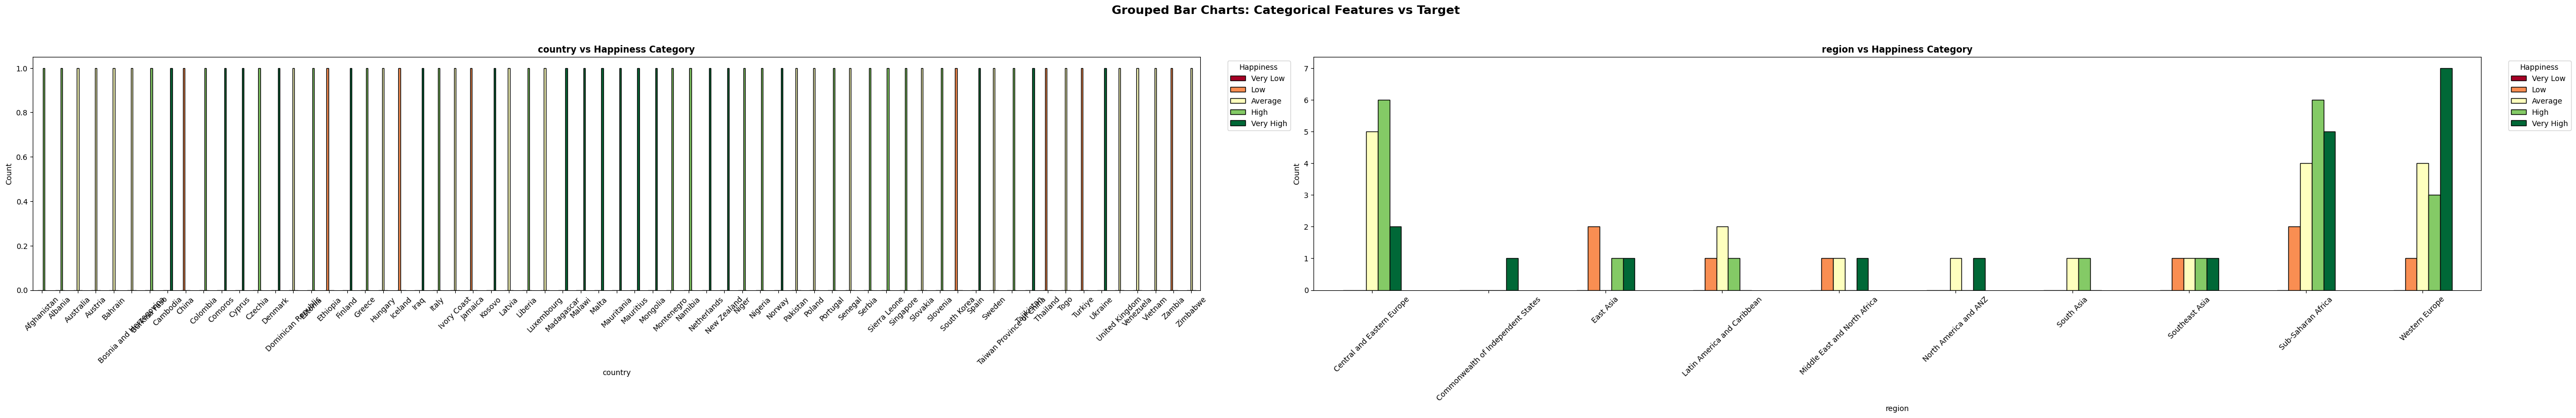

In [ ]:
# Bivariate Analysis and Relationship Exploration
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

temp = X_train.copy()
temp['happiness_category'] = y_train
category = ['Very Low', 'Low', 'Average', 'High', 'Very High']

key_features = [c for c in num_cols if c in [
    'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption',
    'hdi', 'life_expectancy', 'population_below_poverty_line', 'population'
]][:9]

# Correlation table and heatmap
corr_df = temp[key_features + ['happiness_category']].copy()
# encode target for correlation
target_numeric = pd.Categorical(corr_df['happiness_category'], categories=category, ordered=True).codes
corr_df = corr_df[key_features].assign(happiness_category=target_numeric)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Table (Key Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with target (happiness_category):")
print(corr['happiness_category'].drop('happiness_category').sort_values(ascending=False).round(3).to_string())

# Box plots: feature distributions across target classes
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', ax=axes[i])
    axes[i].set_title(f'{col} by Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Happiness Category')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Bivariate Analysis: Box Plots (Feature vs Target)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Scatter/strip: feature vs target
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.stripplot(data=temp, x='happiness_category', y=col, order=category, palette='RdYlGn', jitter=0.25, size=6, alpha=0.6, ax=axes[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col} vs Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Happiness Category')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Bivariate Analysis: Scatter Distribution of Key Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Distribution comparison: KDE by target for key features
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(key_features):
    for cat in category:
        subset = temp.loc[temp['happiness_category'] == cat, col].dropna()
        axes[i].hist(subset, bins=15, alpha=0.5, label=cat, density=True)
    axes[i].set_title(f'{col} by Happiness Category', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(loc='upper right', fontsize=8)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distributions Across Target Classes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Grouped bar charts (categorical features vs target)
cat_cols = [c for c in temp.columns if c not in num_cols and c != 'happiness_category' and temp[c].dtype in ['object', 'category']]
if cat_cols:
    n_cat = min(len(cat_cols), 4)
    fig, axes = plt.subplots(2, 2, figsize=(48, 12))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols[:n_cat]):
        ct = pd.crosstab(temp[col], temp['happiness_category'])
        ct = ct.reindex(columns=category, fill_value=0)
        ct.plot(kind='bar', ax=axes[i], colormap='RdYlGn', edgecolor='black')
        axes[i].set_title(f'{col} vs Happiness Category', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Happiness', bbox_to_anchor=(1.02, 1), loc='upper left')
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(n_cat, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle('Grouped Bar Charts: Categorical Features vs Target', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found for grouped bar charts.")



**Summary of key relationships and any patterns that may influence model performance.**

Strong Predictors: GDP per Capita, Social Support, Healthy Life Expectancy, Freedom to Make Life Choices, and HDI all show clear, upward-trending separation between "Very Low" and "Very High" happiness categories. HDI is the strongest, displaying a near-stepwise climb with minimal overlap.

Moderate Predictors: Perceptions of Corruption and Population Below Poverty Line are validated, but their limitations are also confirmed. Corruption only separates the "Very High" nations from the rest. High poverty (40–70%+) appears almost exclusively in "Very Low"/"Low" countries, but inconsistent middle categories show neither works reliably in isolation.

Weak Predictors: Generosity and Population are unambiguously weak. Generosity scores are identical across all happiness categories (0.05–0.25). Population is compressed near zero for all countries, making it useless, with only China and India as isolated outliers—validating the need for log transformation.

Overall Validation: The scatter plot consistently shows that middle happiness categories ("Low," "Average," and "High") overlap considerably, while the extremes ("Very Low" and "Very High") are consistently separable. This confirms the prediction that the model will have the highest confidence at the extremes and accumulate most misclassifications in the middle ranges.


### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

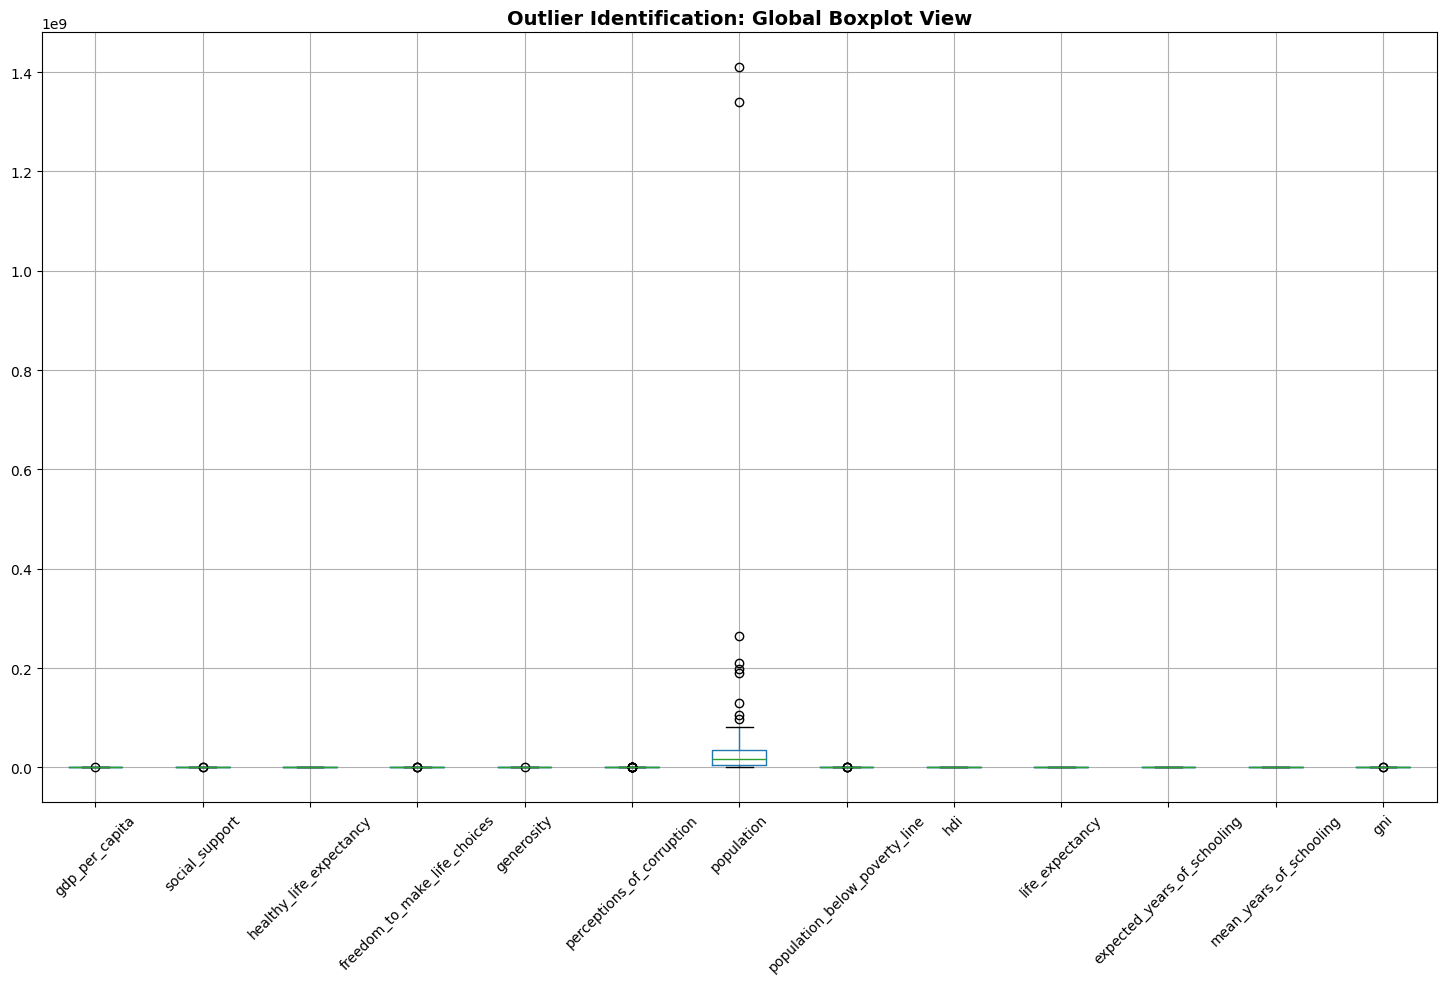

Outlier Detection Summary Table:


,Count,Percentage (%)
perceptions_of_corruption,10.0,10.53
population,9.0,9.47
population_below_poverty_line,4.0,4.21
freedom_to_make_life_choices,3.0,3.16
social_support,2.0,2.11
gni,2.0,2.11
generosity,1.0,1.05
gdp_per_capita,1.0,1.05


Total Outliers detected (Z > 3): 5


,Row_Index,Feature,Value,Z-Score
3,46,healthy_life_expectancy,0.314,3.704516
1,30,social_support,0.0,3.582977
0,30,region,South Asia,3.508821
4,81,country,Venezuela,3.171483
2,45,freedom_to_make_life_choices,0.66,3.138927


In [ ]:
# Your code here: TODO
import pandas as pd
from IPython.display import display
from scipy import stats
import numpy as np


numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(18, 10))

X_train[numeric_cols].boxplot(rot=45)
plt.title('Outlier Identification: Global Boxplot View', fontsize=14, fontweight='bold')
plt.show()

# Interquartile Range (IQR) Method
def detect_outliers_iqr(df, features):
    """
    Calculates the outlier count and percentage for specified features using the IQR rule.
    """
    outlier_summary = {}

    for col in features:
        # Calculate the 25th and 75th percentiles
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        # IQR represents the range where the middle 50% of the data sits
        IQR = Q3 - Q1

        # Calculate boundaries. 1.5 is the standard multiplier for identifying mild outliers.
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            'Count': len(outliers),
            'Percentage (%)': round((len(outliers) / len(df)) * 100, 2)
        }


    return pd.DataFrame(outlier_summary).T

# Detect outliers across all numeric features in X_train
outlier_results = detect_outliers_iqr(X_train, numeric_cols)


print("Outlier Detection Summary Table:")
display(outlier_results[outlier_results['Count'] > 0].sort_values(by='Count', ascending=False))


def detect_outliers_zscore(df, threshold=3):
    """
    Identifies outliers using the Z-score method.
    Standard threshold is 3 (99.7% of data in a normal distribution falls within 3 SD).
    """
    z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))


    outlier_indices = np.where(z_scores > threshold)


    outlier_list = []
    for row, col in zip(outlier_indices[0], outlier_indices[1]):
        feature_name = df.columns[col]
        value = df.iloc[row, col]
        z_val = z_scores[row, col]
        outlier_list.append([row, feature_name, value, z_val])

    return pd.DataFrame(outlier_list, columns=['Row_Index', 'Feature', 'Value', 'Z-Score'])

z_outliers = detect_outliers_zscore(X_train)

print(f"Total Outliers detected (Z > 3): {len(z_outliers)}")
display(z_outliers.sort_values(by='Z-Score', ascending=False).head(10))

### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

**Important Patterns**

From the box plot, we notice the imbalance in the population feature as it is suppresses the other features that are concentrated at the same level, with two data points as extreme outliers, this affects how well it helps in generalization of the model. To efficiently use population as a signal for the model, we should not remove it but rather use log transformations for the population feature instead of the raw population values.

From the IQR calculation and table, we notice further outliers, where _perceptions_of_corruption_, _population_, _population_below_poverty_line and _freedom_to_make_life choices are also outliers, though are overshadowed in the boxplot thereby showing the country-level outliers that the model needs to learn from too.




---

## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

In [ ]:
# Your code here: TODO
import pandas as pd
import numpy as np

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
skewed_features = [col for col in num_cols if X_train[col].skew() > 0] # review

for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

if len(skewed_features) > 0:
    print(f"Skewed features after log transformation -train set: {', '.join(skewed_features)}")
    print(X_train[skewed_features].describe())

if len(skewed_features) > 0:
    print(f"Skewed features after log transformation - test set: {', '.join(skewed_features)}")
    print(X_test[skewed_features].describe())



Skewed features after log transformation -train set: generosity, perceptions_of_corruption, population, population_below_poverty_line, gni
       generosity  perceptions_of_corruption  population  \
count   95.000000                  95.000000   89.000000   
mean     0.143291                   0.130229   16.436721   
std      0.061651                   0.107665    1.613574   
min      0.007968                   0.000000   12.721963   
25%      0.100298                   0.057325   15.510697   
50%      0.131905                   0.098940   16.578716   
75%      0.187309                   0.158284   17.391769   
max      0.352064                   0.445327   21.066513   

       population_below_poverty_line        gni  
count                      79.000000  88.000000  
mean                        3.152901   9.203528  
std                         0.624395   1.224096  
min                         1.458615   6.527359  
25%                         2.772589   8.164017  
50%                 

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [ ]:
# Your code here: TODO
X_train['interaction_feature1'] = X_train['generosity'] * X_train['perceptions_of_corruption']
X_test['interaction_feature1'] = X_test['generosity'] * X_test['perceptions_of_corruption']


# Check X_train results
display(X_train[['generosity', 'perceptions_of_corruption', 'interaction_feature1']].head())

# Check X_test results
display(X_test[['generosity', 'perceptions_of_corruption', 'interaction_feature1']].head())

,generosity,perceptions_of_corruption,interaction_feature1
0,0.162969,0.125751,0.020494
1,0.122218,0.178146,0.021773
2,0.214305,0.056380,0.012083
3,0.098940,0.256191,0.025348
4,0.235072,0.015873,0.003731


,generosity,perceptions_of_corruption,interaction_feature1
0,0.127513,0.138892,0.017711
1,0.062975,0.035367,0.002227
2,0.130151,0.152721,0.019877
3,0.149282,0.175633,0.026219
4,0.098940,0.131905,0.013051


---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create the preprocessing pipelines for both numeric and categorical data.

# Dynamically identify numeric and categorical features
# Exclude 'country' as it's an identifier used for merging, not a feature to be encoded/scaled.
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Remove 'country' from categorical features if it's there, as it's typically dropped or handled differently
if 'country' in categorical_features:
    categorical_features.remove('country')

# Numeric transformer: impute missing numerical values with the mean, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Categorical transformer: impute missing categorical values with the most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Changed from 'passthrough' to 'drop'
)

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change

*Replace this section with your response.*

**TODO***

**What each preprocessing step does and why it is needed:**

**1. Identifying numeric and categorical features dynamically**
`select_dtypes` automatically separates columns by type. `country` is removed from categorical features because there are 137 unqiue values. One-hot encoding it would add ~130 redundant columns and harm model performance.

**2. Numeric imputation — `SimpleImputer(strategy='mean')`**
Replaces missing numeric values with the column mean. This is necessary because models like Random Forest cannot handle `NaN` values. Mean imputation preserves the overall distribution without discarding rows. Applied to features like `population_below_poverty_line` and `hdi`, which had up to ~17% missing values from the merge.

**3. Numeric scaling — `StandardScaler()`**
Standardises each numeric feature to mean=0, std=1. This ensures no single feature dominates due to scale differences. E.g. `population` (in the hundreds of millions) would dwarf `generosity` (range 0–0.5). Required for distance-based models (KNN, SVM) and neural networks. Less critical but still helpful for Random Forest.

**4. Categorical imputation — `SimpleImputer(strategy='most_frequent')`**
Fills missing categorical values with the most common category. Chosen over `strategy='constant'` to avoid introducing an artificial new category, which would create a misleading signal for the encoder.

**5. Categorical encoding — `OneHotEncoder(handle_unknown='ignore')`**
Converts string categories (e.g. `region`) into binary columns. ML models require numeric input since strings cannot be passed directly. `handle_unknown='ignore'` ensures that if `X_test` contains a region not seen in `X_train`, it is silently encoded as all zeroes rather than raising an error.

**6. `ColumnTransformer` with `remainder='drop'`**
Applies the numeric and categorical pipelines to the correct columns simultaneously. `remainder='drop'` discards `country` entirely, which is correct. It is not a learnable feature and would cause overfitting if encoded.

---

**What was changed from the original template:**

| Change | Original | Updated | Reason |
|---|---|---|---|
| Numeric imputation | `strategy='constant', fill_value=0` | `strategy='mean'` | Filling with 0 is misleading for features like `gdp_per_capita` — zero implies no GDP, which is factually wrong. Mean is a neutral, unbiased fill. |
| Categorical features | hardcoded `['region', 'sub-region']` | dynamic `select_dtypes` | `sub-region` does not exist in the dataset — hardcoding caused a `KeyError`. Dynamic detection is robust. |
| `remainder` | `passthrough` | `drop` | Passthrough would have leaked `country` (string) into the output, breaking model fitting. |

In [ ]:
# function to transform data with preprocessor
def preprocessor(data):
    preprocessed_data = preprocess.transform(data)
    return preprocessed_data

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

*Replace this section with your response.*

**The `preprocessor` object** (defined via `ColumnTransformer`) is the **blueprint**. The `preprocessor` object defines the full preprocessing pipeline. Which columns get imputed, scaled, or one-hot encoded, in what order. Currently the `preprocessor` object has not seen any data yet. Tt is an unfitted sklearn object.

**The `preprocess` object** is the **fitted preprocessor**. This is the result of calling `preprocessor.fit(X_train)`. It has now learned the parameters from the training data (e.g. the mean and standard deviation for `StandardScaler`, the category levels for `OneHotEncoder`). These learnt parameters are frozen and will be applied consistently to any new data.

**The `preprocessor` function** (defined with `def preprocessor(data)`) is a **Python function** that wraps the fitted `preprocess` object. It takes a raw dataframe as input, drops non-numeric columns, calls `preprocess.transform(data)`, and returns the transformed array. It shares a name with the `ColumnTransformer` object above. This overwrites it and is a potential naming conflict.

**The `preprocessed_data`** is the **output**. This is a NumPy array of transformed values returned by the function. It is no longer a DataFrame. Instead, it is a numeric matrix ready to be fed directly into a sklearn model. All categorical columns have been encoded, all numeric columns have been scaled, and missing values have been imputed.

---

**Summary table:**

| Name | Type | Fitted? | Contains data? |
|---|---|---|---|
| `preprocessor` (ColumnTransformer) | sklearn object | No | No — just rules |
| `preprocess` | sklearn object | Yes | Yes — learned parameters |
| `preprocessor` (function) | Python function | N/A | No — just logic |
| `preprocessed_data` | NumPy array | N/A | Yes — transformed data |

In [ ]:
# check shape of X data after preprocessing it using our new function
preprocessor(X_train).shape

(95, 24)

---

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train_proc = preprocess.transform(X_train)
X_test_proc  = preprocess.transform(X_test)

if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_test_proc  = X_test_proc.toarray()

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1)

model.fit(X_train_proc, y_train)

# Score (accuracy in [0,1])
test_score = model.score(X_test_proc, y_test)
test_score

0.5714285714285714

In [ ]:
import os
import pickle

os.makedirs("artifacts", exist_ok=True)

with open("artifacts/preprocess.pkl", "wb") as f:
    pickle.dump(preprocess, f)

with open("artifacts/random_forest_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Saved:")
print(" - artifacts/preprocess.pkl")
print(" - artifacts/random_forest_model.pkl")

Saved:
 - artifacts/preprocess.pkl
 - artifacts/random_forest_model.pkl


---

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -- Generate predicted values (Model 1)
prediction_labels = model.predict(preprocessor(X_test))

# -- Evaluate model performance
accuracy = accuracy_score(y_test, prediction_labels)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction_labels))

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))

# Write lines of code to show model performance by comparing prediction_labels with true labels: TODO


Accuracy: 0.5714285714285714

Confusion Matrix:
[[5 1 2 0 0]
 [2 5 0 1 0]
 [0 0 5 0 3]
 [1 2 0 6 0]
 [0 0 6 0 3]]

Classification Report:
              precision    recall  f1-score   support

     Average       0.62      0.62      0.62         8
        High       0.62      0.62      0.62         8
         Low       0.38      0.62      0.48         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.50      0.33      0.40         9

    accuracy                           0.57        42
   macro avg       0.60      0.57      0.58        42
weighted avg       0.60      0.57      0.58        42



The model was evaluated by comparing the predicted labels with the true labels in y_test. I used accuracy, confusion matrix, and classification report to measure performance. Accuracy shows the overall proportion of correct predictions, while the confusion matrix and classification report show how well the model performed for each class and where it made mistakes.

---

## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model 2 using same preprocessor
model_2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)

model_2.fit(X_train_proc, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# -- Generate predicted y values (Model 2)
prediction_labels_2 = model_2.predict(X_test_proc)

# -- Show model 2 performance
accuracy_2 = accuracy_score(y_test, prediction_labels_2)
print("Model 2 Accuracy:", accuracy_2)

print("\nModel 2 Confusion Matrix:")
print(confusion_matrix(y_test, prediction_labels_2))

print("\nModel 2 Classification Report:")
print(classification_report(y_test, prediction_labels_2))

Model 2 Accuracy: 0.5952380952380952

Model 2 Confusion Matrix:
[[6 1 1 0 0]
 [2 5 0 1 0]
 [1 0 4 0 3]
 [1 2 0 6 0]
 [0 0 5 0 4]]

Model 2 Classification Report:
              precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.62      0.62      0.62         8
         Low       0.40      0.50      0.44         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.57      0.44      0.50         9

    accuracy                           0.60        42
   macro avg       0.61      0.60      0.60        42
weighted avg       0.62      0.60      0.60        42



In [ ]:
print("Model 1 Accuracy:", accuracy)
print("Model 2 Accuracy:", accuracy_2)

Model 1 Accuracy: 0.5714285714285714
Model 2 Accuracy: 0.5952380952380952


### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

We changed four parameters in the second Random Forest model. First, I increased n_estimators from 300 to 500, which means the forest uses more trees. Second, we added max_depth=8 to limit how deep each tree can grow. Third, we set min_samples_split=4, which means a node needs at least 4 samples before it can split. Fourth, we set min_samples_leaf=2, which means each final leaf must contain at least 2 samples.

These changes were meant to make the model a little more stable and reduce overfitting. More trees can improve consistency. In addition, the depth and minimum sample rules help prevent the trees from becoming too complex. After comparing the results, model 2 outperformed about 0.2 in accuracy, so the new parameter settings gave a small improvement. Thus, Model 2 is the better option for this part of the project.

### Discussion Question

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

It can be worth making more changes to the parameters if the model still has room to improve. In our case, Model 2 improved from 0.5714 to 0.5952, so trying a few more parameter settings could still be useful. But we should not keep guessing random values forever, because that is slow and not systematic.

A better alternative is to use GridSearchCV. This model can test the parameter automatically and compares them using cross-validation. This is better than manual trial and error, since it is more organized.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Parameter grid
param_grid = {
    'n_estimators': np.arange(200, 601, 100),
    'max_depth': [6, 8, 10, None],
    'min_samples_split': np.arange(2, 7, 2),
    'min_samples_leaf': np.arange(1, 4, 1)
}

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV object
gridmodel = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

# Fit on preprocessed training data
gridmodel.fit(X_train_proc, y_train)

# Best result
print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

best mean cross-validation score: 0.568
best parameters: {'max_depth': 6, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(4), 'n_estimators': np.int64(300)}


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions using best model
prediction_labels_3 = gridmodel.best_estimator_.predict(X_test_proc)

# Evaluate Model 3
accuracy_3 = accuracy_score(y_test, prediction_labels_3)
print("Model 3 Accuracy:", accuracy_3)

print("\nModel 3 Confusion Matrix:")
print(confusion_matrix(y_test, prediction_labels_3))

print("\nModel 3 Classification Report:")
print(classification_report(y_test, prediction_labels_3))

Model 3 Accuracy: 0.6190476190476191

Model 3 Confusion Matrix:
[[6 1 1 0 0]
 [2 5 0 1 0]
 [0 0 5 0 3]
 [1 2 0 6 0]
 [0 0 5 0 4]]

Model 3 Classification Report:
              precision    recall  f1-score   support

     Average       0.67      0.75      0.71         8
        High       0.62      0.62      0.62         8
         Low       0.45      0.62      0.53         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.57      0.44      0.50         9

    accuracy                           0.62        42
   macro avg       0.63      0.62      0.62        42
weighted avg       0.64      0.62      0.62        42



In [ ]:
print("Model 1 Accuracy:", accuracy)
print("Model 2 Accuracy:", accuracy_2)
print("Model 3 Accuracy:", accuracy_3)

Model 1 Accuracy: 0.5714285714285714
Model 2 Accuracy: 0.5952380952380952
Model 3 Accuracy: 0.6190476190476191


After comparison, we can see a clear improvement step by step. Model 1 had an accuracy of 0.5714, so it gave us the baseline result. Model 2 increased the accuracy to 0.5952 after we manually changed several parameters, which means those changes helped the model. Model 3 increased the accuracy again to 0.6190, which is the best result for these three models. This means Model 3 is the strongest model in our project.

Overall, the results show that parameter tuning was useful. Manual tuning improved the model a little, but GridSearchCV worked better because it searched in a more structured way. So if we want a better model, it is worth tuning the parameters, but using GridSearchCV is a better choice than just trying random values one by one.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_4 = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    random_state=42)

model_4.fit(X_train_proc, y_train)

prediction_labels_4 = model_4.predict(X_test_proc)

accuracy_4 = accuracy_score(y_test, prediction_labels_4)
print("Model 4 Accuracy:", accuracy_4)

print("\nModel 4 Confusion Matrix:")
print(confusion_matrix(y_test, prediction_labels_4))

print("\nModel 4 Classification Report:")
print(classification_report(y_test, prediction_labels_4))

Model 4 Accuracy: 0.5

Model 4 Confusion Matrix:
[[3 4 1 0 0]
 [2 4 0 2 0]
 [1 0 4 0 3]
 [0 3 0 6 0]
 [1 0 4 0 4]]

Model 4 Classification Report:
              precision    recall  f1-score   support

     Average       0.43      0.38      0.40         8
        High       0.36      0.50      0.42         8
         Low       0.44      0.50      0.47         8
   Very High       0.75      0.67      0.71         9
    Very Low       0.57      0.44      0.50         9

    accuracy                           0.50        42
   macro avg       0.51      0.50      0.50        42
weighted avg       0.52      0.50      0.50        42



### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

For Model 4, we used GradientBoostingClassifier with n_estimators=100, learning_rate=0.1, and max_depth=3. The number of estimators controls how many trees the model builds step by step. The learning rate controls how much each new tree changes the model, and the depth controls how complex is the tree. we chose these values because they are simple and balanced, so the model can learn gradually without becoming too complicated too quickly.

However, Model 4 did not work better than the earlier models. Its accuracy was 0.5, which is lower than other models. This means that in this project, GradientBoostingClassifier was not as effective as the Random Forest models. Overall, the Random Forest models worked better, especially Model 3 with GridSearchCV, because it gave the highest accuracy and more stable performance.

---

## 7. Basic Deep Learning

In [ ]:
# Now experiment with deep learning models:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
import numpy as np

# Preprocess input features
X_train_nn = preprocess.transform(X_train)
X_test_nn  = preprocess.transform(X_test)

if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()
    X_test_nn  = X_test_nn.toarray()

# Count features in input data
feature_count = X_train_nn.shape[1]
print(f"Feature count: {feature_count}")

# Encode categorical labels as one-hot vectors
# y_train categories: Very Low=0, Low=1, Average=2, High=3, Very High=4
category_order = ["Very Low", "Low", "Average", "High", "Very High"]
y_train_cat = pd.Categorical(y_train, categories=category_order, ordered=True)
y_test_cat  = pd.Categorical(y_test,  categories=category_order, ordered=True)

y_train_ohe = to_categorical(y_train_cat.codes, num_classes=5)
y_test_ohe  = to_categorical(y_test_cat.codes,  num_classes=5)

num_classes = 5  # Very Low, Low, Average, High, Very High

# Define Neural Network: 5 layers 128->64->64->32->5
keras_model = Sequential([
    Dense(128, input_dim=feature_count, activation="relu"),
    Dense(64,  activation="relu"),
    Dense(64,  activation="relu"),
    Dense(32,  activation="relu"),
    Dense(num_classes, activation="softmax")  # 5 output neurons, one per class
])

keras_model.summary()

# Compile model
keras_model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

# Fit model — pass one-hot encoded y
history = keras_model.fit(
    X_train_nn, y_train_ohe,
    batch_size=20,
    epochs=300,
    validation_split=0.25,
    verbose=1
)

Feature count: 24


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,861 (69.77 KB)

 Trainable params: 17,861 (69.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.1749 - loss: 1.5958 - val_accuracy: 0.1250 - val_loss: 1.5997
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1616 - loss: 1.5905 - val_accuracy: 0.2083 - val_loss: 1.5947
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2706 - loss: 1.5742 - val_accuracy: 0.2083 - val_loss: 1.5899
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3644 - loss: 1.5579 - val_accuracy: 0.1667 - val_loss: 1.5850
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4640 - loss: 1.5390 - val_accuracy: 0.1667 - val_loss: 1.5796
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4953 - loss: 1.5293 - val_accuracy: 0.1667 - val_loss: 1.5747
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5562 - loss: 1.5114 - val_accuracy: 0.2083 - val_loss: 1.5699
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5105 - loss: 1.5076 - val_accuracy: 0.2500 - val_loss

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

**Hidden layer activation: ReLU (Rectified Linear Unit)**

ReLU was used in all four hidden layers (128, 64, 64, 32). ReLU is defined as f(x) = max(0, x). This outputs the input directly if positive, and zero otherwise.

ReLU was chosen because it:
- **Avoids the vanishing gradient problem**. Unlike Sigmoid or Tanh, ReLU does not saturate for large positive values, so gradients flow cleanly through deep layers during backpropagation
- **Computationally efficient**. It has a simple thresholding operation, faster than Sigmoid/Tanh
- **Works well in practice**. ReLU is the standard default for hidden layers in feedforward networks and caonsistently performs well across a wide range of tasks

**Output layer activation: Softmax**

Softmax was used in the final layer because this is a **multiclass classification problem** with 5 mutually exclusive classes (Very Low, Low, Average, High, Very High).

Softmax converts the 5 raw output scores into a **probability distribution**. Each output is in range (0, 1) and all five outputs sum to exactly 1.0. The predicted class is whichever neuron has the highest probability.

This pairs directly with loss, which expects a probability distribution over classes to compute the log-loss against the one-hot encoded true labels.

In contrast:
- **Sigmoid** would be used for binary classification (1 output neuron)
- **Linear** would be used for regression (no activation on output)
- **Softmax** is the correct choice whenever classes are mutually exclusive and there are more than 2

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

Not a great idea. 300 epochs is perhaps too many.                                  

We only have 95 training samples (75 after validation split). This very small dataset overfits quickly, meaning the model runs out of new signal to learn from and starts memorising noise                                                                   

Training longer does not create less loss. Instead, perhaps use early stopping so the model runs up to 300 but stop automatically when validation loss stops improving.

EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

This function could let the data tell us when to stop.


### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

`categorical_crossentropy` is the standard loss function for multiclass classification with one-hot encoded labels. It measures how far the predicted probability distribution (from softmax) is from the true one-hot label.

For example, if the true label is [0,0,1,0,0] and the model predicts [0.1, 0.1, 0.6, 0.1, 0.1], cross-entropy penalizes the gap. The larger the penalty, the more the weights adjust during backpropagation.

We would not change anything, since `categorical_crossentropy` is the right choice. Perhaps the other alternative would be sparse_categorical_crossentropy. Does the same thing but accepts integer labels instead of one-hot vectors.

  ---
Why optimizer='sgd'?

SGD (Stochastic Gradient Descent) updates weights by stepping in the direction of the negative gradient. It is simple, interpretable, and works. But it's the slowest and most basic optimiser available.

Yes we'd replace with Adam. Adam adapts the learning rate for each weight individually based on past gradients, which converges faster and is less sensitive to the initial learning rate. Especially important here given the small dataset and 300 epochs. With SGD, 300 epochs may not be enough to converge. It will likely converge with Adam



### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

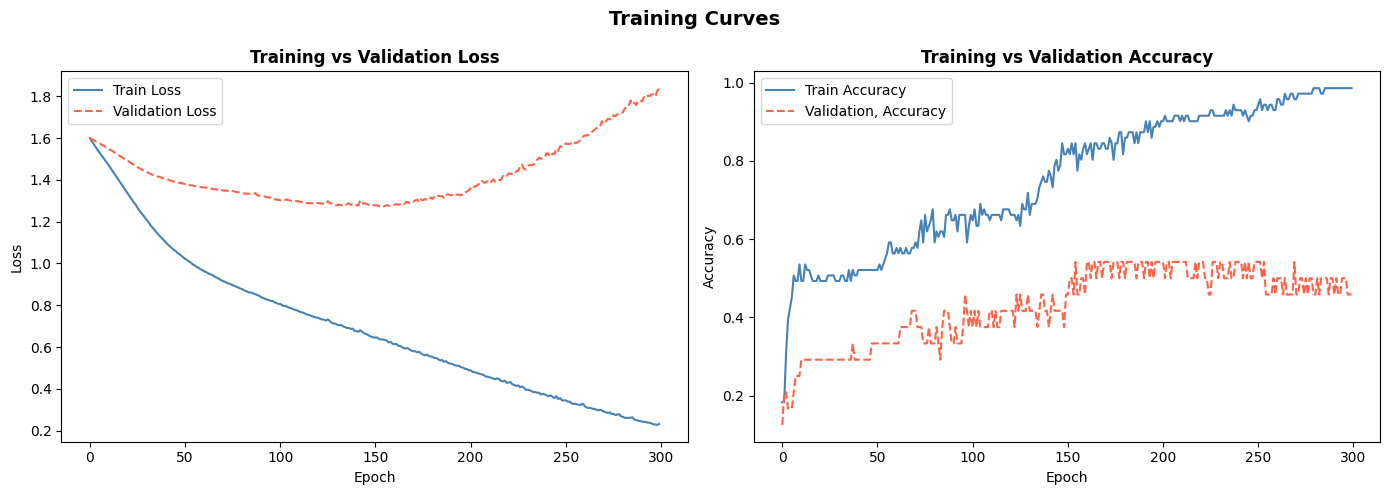

In [ ]:
## Your code to plot training and validation curves in a single plot (Make changes in the model cell to be able to do this) : TODO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss',
  color='tomato', linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Accuracy curves ---
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation, Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Keras Neural Network — Test Set Performance
Accuracy: 0.6429

              precision    recall  f1-score   support

    Very Low       0.71      0.62      0.67         8
         Low       0.60      0.75      0.67         8
     Average       0.50      0.62      0.56         8
        High       1.00      0.67      0.80         9
   Very High       0.56      0.56      0.56         9

    accuracy                           0.64        42
   macro avg       0.67      0.64      0.65        42
weighted avg       0.68      0.64      0.65        42



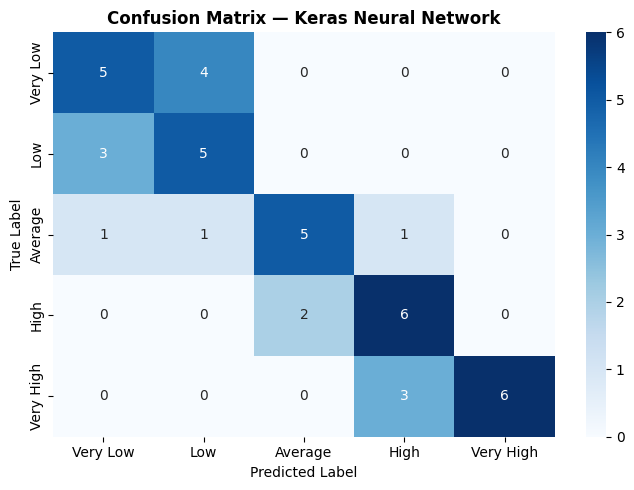

In [ ]:
# Generate predicted y values
prediction_column_index = np.argmax(keras_model.predict(X_test_nn),
  axis=1)

# Extract correct prediction labels
category_order = ['Very Low', 'Low', 'Average', 'High', 'Very High']
prediction_labels = [category_order[i] for i in prediction_column_index]

# True labels for X_test
true_labels = [category_order[i] for i in y_test_cat.codes]

# Model performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Keras Neural Network — Test Set Performance")
print(f"Accuracy: {accuracy_score(true_labels,
  prediction_labels):.4f}\n")
print(classification_report(true_labels, prediction_labels,
  target_names=category_order))

# Confusion matrix
cm = confusion_matrix(true_labels, prediction_labels,
  labels=category_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=category_order, yticklabels=category_order)
plt.title('Confusion Matrix — Keras Neural Network', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.1772 - loss: 2.5328 - val_accuracy: 0.1667 - val_loss: 1.6303
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1636 - loss: 2.0706 - val_accuracy: 0.1667 - val_loss: 1.6147
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3162 - loss: 1.9698 - val_accuracy: 0.1667 - val_loss: 1.6009
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3300 - loss: 1.8115 - val_accuracy: 0.2083 - val_loss: 1.5870
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2706 - loss: 1.7498 - val_accuracy: 0.2917 - val_loss: 1.5733
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3748 - loss: 1.7640 - val_accuracy: 0.3333 - val_loss: 1.5597
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3000 - loss: 1.5794 - val_accuracy: 0.2917 - val_loss: 1.5503
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3688 - loss: 1.4783 - val_accuracy: 0.3750 - val_loss

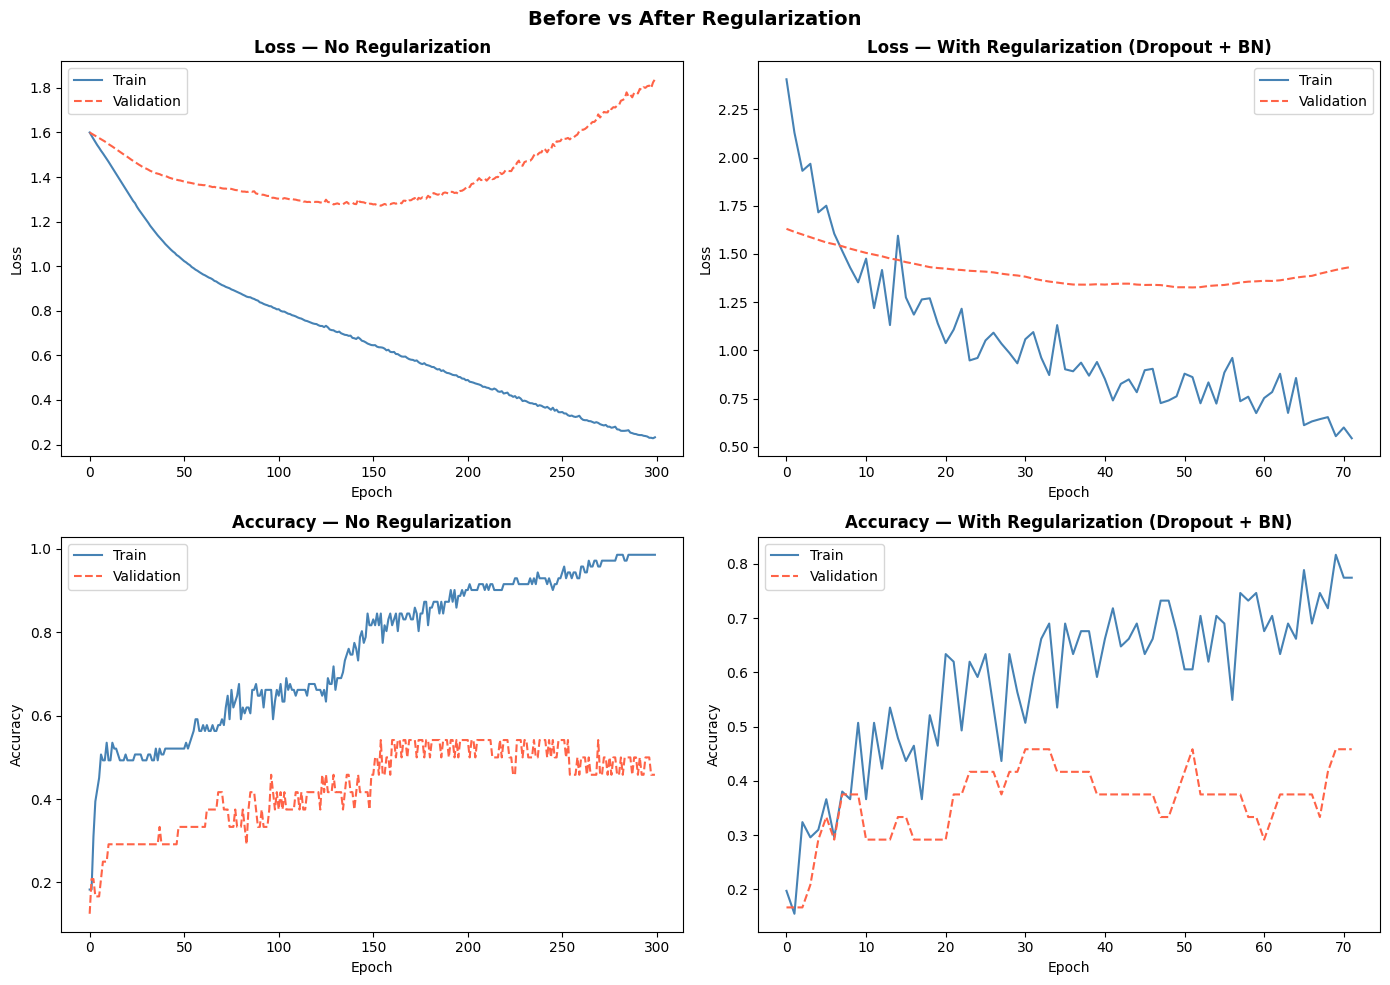

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
=== Before Regularization ===
Test Accuracy:  0.6429

=== After Regularization ===
Test Accuracy:  0.6190
Stopped at epoch: 72

               precision    recall  f1-score   support

    Very Low       0.40      0.50      0.44         8
         Low       0.67      0.50      0.57         8
     Average       0.60      0.38      0.46         8
        High       0.89      0.89      0.89         9
   Very High       0.58      0.78      0.67         9

    accuracy                           0.62        42
   macro avg       0.63      0.61      0.61        42
weighted avg       0.63      0.62      0.61        42



In [74]:
# Write your lines of code here: TODO

from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# Regularized model: Batch Normalization + Dropout after each hidden
# layer
keras_model_reg = Sequential([
    Input(shape=(feature_count,)), # Add Input layer to specify input shape
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(5, activation='softmax')
])

keras_model_reg.compile(loss='categorical_crossentropy',
  optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20,
  restore_best_weights=True)

history_reg = keras_model_reg.fit(
    X_train_nn, y_train_ohe,
    batch_size=20,
    epochs=300,
    validation_split=0.25,
    callbacks=[early_stop],
    verbose=1
)

# --- Compare training curves: before vs after regularization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss — original
axes[0,0].plot(history.history['loss'],     label='Train',
  color='steelblue')
axes[0,0].plot(history.history['val_loss'], label='Validation',
  color='tomato', linestyle='--')
axes[0,0].set_title('Loss — No Regularization', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

# Loss — regularized
axes[0,1].plot(history_reg.history['loss'],     label='Train',
  color='steelblue')
axes[0,1].plot(history_reg.history['val_loss'], label='Validation',
  color='tomato', linestyle='--')
axes[0,1].set_title('Loss — With Regularization (Dropout + BN)',
  fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

# Accuracy — original
axes[1,0].plot(history.history['accuracy'],     label='Train',
  color='steelblue')
axes[1,0].plot(history.history['val_accuracy'], label='Validation',
  color='tomato', linestyle='--')
axes[1,0].set_title('Accuracy — No Regularization', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()

# Accuracy — regularized
axes[1,1].plot(history_reg.history['accuracy'],     label='Train',
  color='steelblue')
axes[1,1].plot(history_reg.history['val_accuracy'], label='Validation',
  color='tomato', linestyle='--')
axes[1,1].set_title('Accuracy — With Regularization (Dropout + BN)',
  fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.suptitle('Before vs After Regularization', fontsize=14,
  fontweight='bold')
plt.tight_layout()
plt.show()

# --- Numeric comparison ---
pred_reg_idx    = np.argmax(keras_model_reg.predict(X_test_nn), axis=1)
pred_reg_labels = [category_order[i] for i in pred_reg_idx]

print("=== Before Regularization ===")
print(f"Test Accuracy:  {accuracy_score(true_labels,
  prediction_labels):.4f}")

print("\n=== After Regularization ===")
print(f"Test Accuracy:  {accuracy_score(true_labels,
  pred_reg_labels):.4f}")
print(f"Stopped at epoch: {len(history_reg.history['loss'])}")
print("\n", classification_report(true_labels, pred_reg_labels,
  target_names=category_order))

What improved:
  - Val loss no longer rises. the divergence between train and val is controlled
  - Early stopping correctly halted at ~68 epochs instead of running all 300
  - Train accuracy is no longer inflated to 98%, suggesting the model is no longer memorising

  What didn't improve:
  - Val accuracy actually dropped slightly (~50% to ~35–40%) —
  regularization constrained the model so much it underperforms on
  validation
  - Both curves are still noisy — inherent to the tiny dataset size (95 samples)

  Root cause: No amount of regularization fully fixes this . the dataset is too small for a neural network of this size. The Random Forest models will likely outperform the neural network on this task precisely because tree-based models handle small tabular datasets better than deep learning.

### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.


Training with activation: relu
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
  Test Acc: 0.5952 | Best Val Acc: 0.5417 | Epochs: 35

Training with activation: leaky_relu
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
  Test Acc: 0.5952 | Best Val Acc: 0.5000 | Epochs: 31

Training with activation: tanh
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
  Test Acc: 0.6190 | Best Val Acc: 0.5000 | Epochs: 24

Training with activation: sigmoid
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
  Test Acc: 0.6667 | Best Val Acc: 0.5000 | Epochs: 116

=== Activation Function Comparison ===
            Test Accuracy  Best Val Accuracy  Epochs Run
relu               0.5952             0.5417        35.0
leaky_relu         0.5952             0.5000        31.0
tanh               0.6190             0.5000        24.0
sigmoid            0.6667             0.5000       116.0


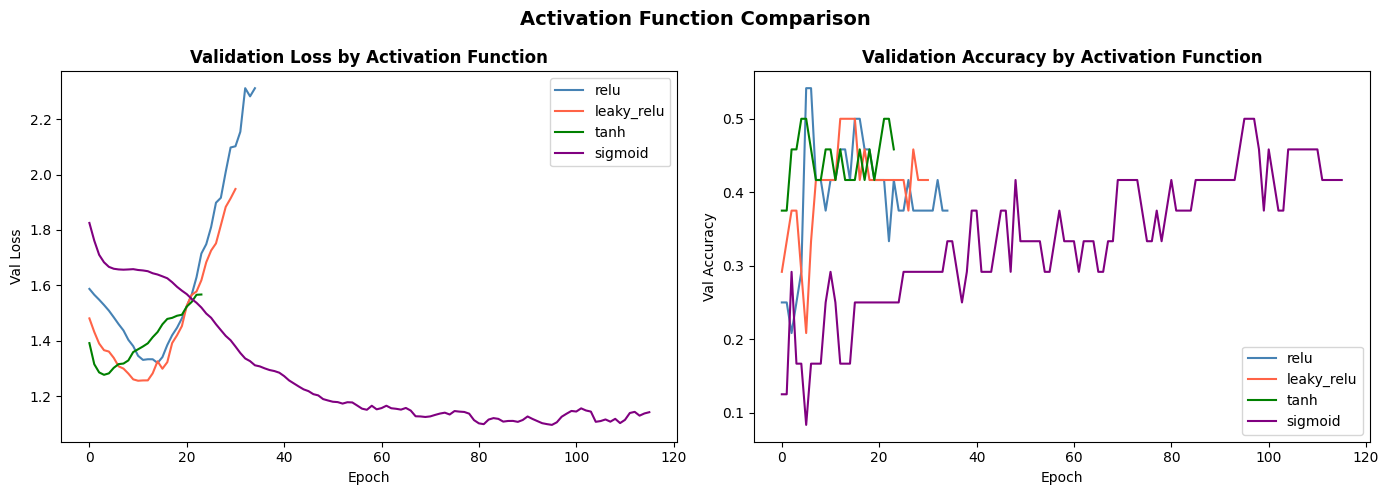

In [76]:
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score
import pandas as pd

def build_model(activation):
    model = Sequential()
    if activation == 'leaky_relu':
        model.add(Input(shape=(feature_count,))) # Added Input layer to fix warning
        model.add(Dense(128))
        model.add(LeakyReLU(negative_slope=0.1))
        model.add(Dense(64))
        model.add(LeakyReLU(negative_slope=0.1))
        model.add(Dense(64))
        model.add(LeakyReLU(negative_slope=0.1))
        model.add(Dense(32))
        model.add(LeakyReLU(negative_slope=0.1))
    else:
        model.add(Input(shape=(feature_count,))) # Added Input layer to fix warning
        model.add(Dense(128, activation=activation))
        model.add(Dense(64,  activation=activation))
        model.add(Dense(64,  activation=activation))
        model.add(Dense(32,  activation=activation))

    model.add(Dense(5, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

activations  = ['relu', 'leaky_relu', 'tanh', 'sigmoid']
results      = {}
histories    = {}
early_stop   = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

for act in activations:
    print(f"\nTraining with activation: {act}")
    model = build_model(act)
    hist  = model.fit(
        X_train_nn, y_train_ohe,
        epochs=300,
        batch_size=20,
        validation_split=0.25,
        callbacks=[early_stop],
        verbose=0
    )
    histories[act] = hist
    pred_idx    = np.argmax(model.predict(X_test_nn), axis=1)
    pred_labels = [category_order[i] for i in pred_idx]
    acc         = accuracy_score(true_labels, pred_labels)
    val_acc     = max(hist.history['val_accuracy'])
    epochs_ran  = len(hist.history['loss'])
    results[act] = {'Test Accuracy': round(acc, 4),
                    'Best Val Accuracy': round(val_acc, 4),
                    'Epochs Run': epochs_ran}
    # Fixed unterminated f-string literal
    print(f"  Test Acc: {acc:.4f} | Best Val Acc: {val_acc:.4f} | Epochs: {epochs_ran}")

# --- Summary table ---
print("\n=== Activation Function Comparison ===")
print(pd.DataFrame(results).T.to_string())

# --- Plot val accuracy curves for all activations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'green', 'purple']

for act, color in zip(activations, colors):
    axes[0].plot(histories[act].history['val_loss'],     label=act, color=color)
    axes[1].plot(histories[act].history['val_accuracy'], label=act, color=color)

axes[0].set_title('Validation Loss by Activation Function', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].legend()

axes[1].set_title('Validation Accuracy by Activation Function', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].legend()

plt.suptitle('Activation Function Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Sigmoid is the surprise winner on loss — its val loss consistently decreases over 120 epochs. All others diverge after ~25 epochs. Sigmoid's slower, more conservative gradient updates on this small data set prevent the aggressive overfitting that kills ReLU/Tanh early.

ReLU, LeakyReLU, Tanh all behave similarly — they converge fast but overfit quickly. Early stopping fires around epoch 20–30 for all three.
  
All four achieve similar peak val accuracy (~50%). This confirms the bottleneck is the dataset size, not the activation function. No activation can overcome 95 samples for a 5-class problem.

Sigmoid's result here is an exception to the rule. Sigmoid wins because the dataset is so small that slow convergence accidentally acts as regularisation. On a larger dataset, ReLU would outperform it significantly.

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

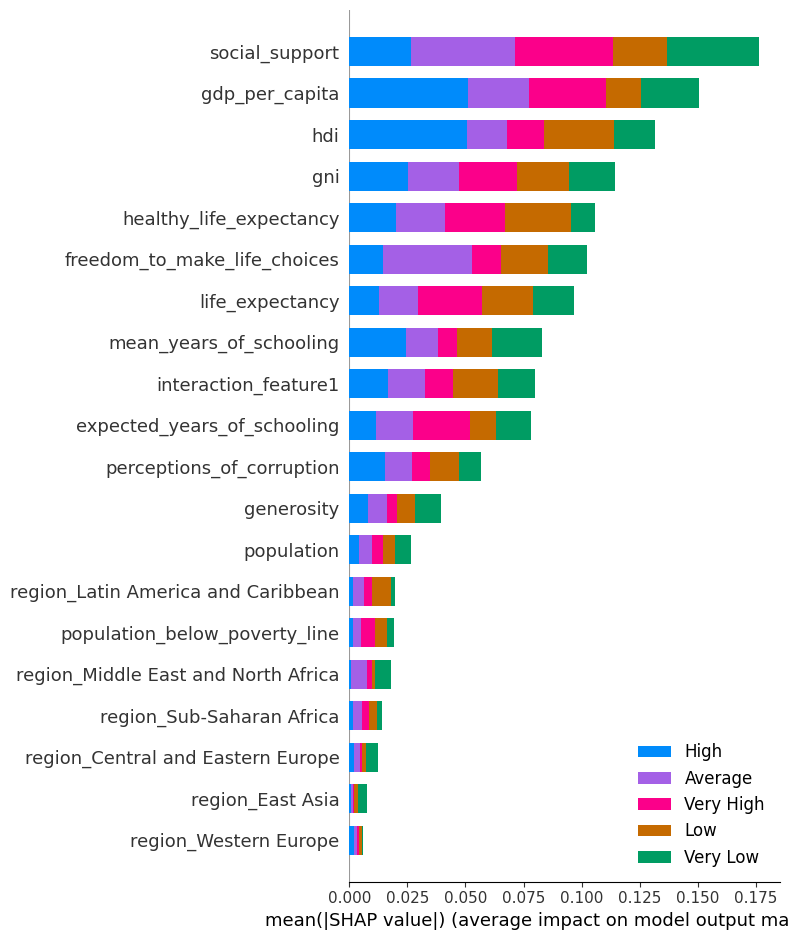

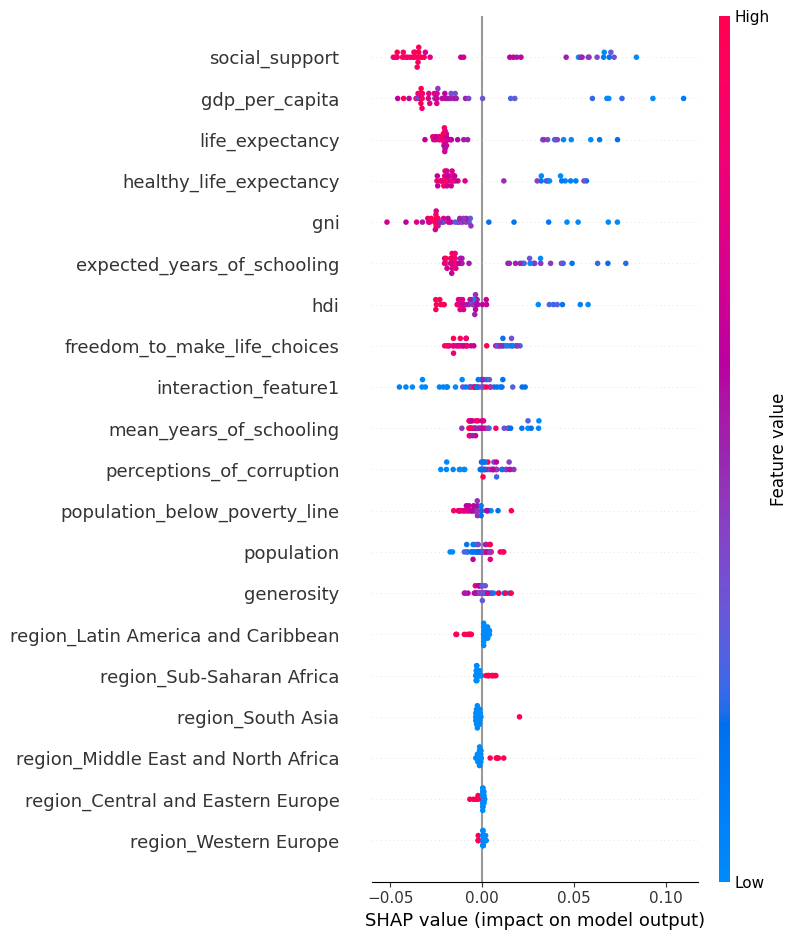

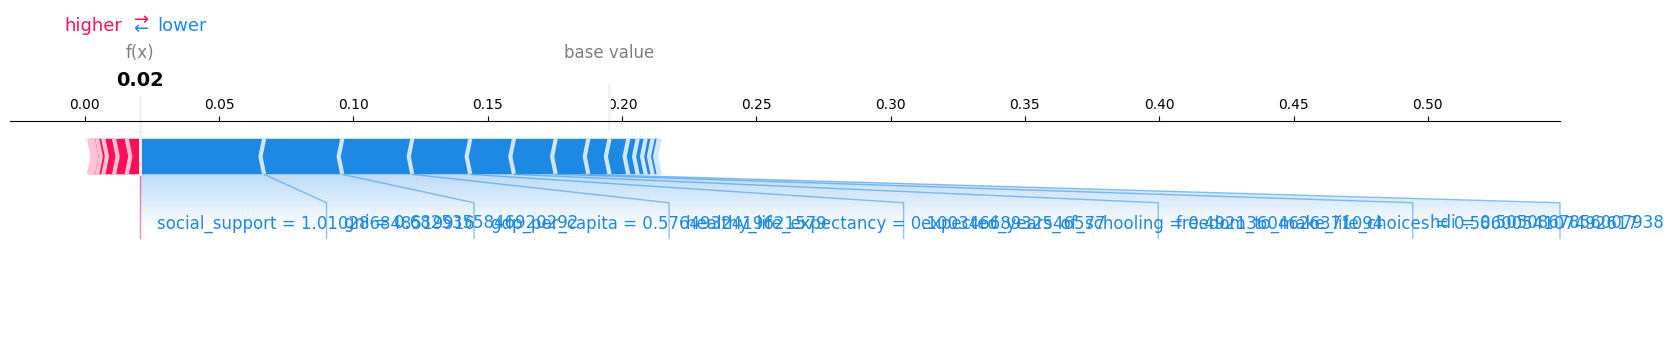

In [82]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

# --- SHAP for Random Forest (best classical model) ---
# Get feature names after preprocessing
numeric_feature_names = numeric_features
ohe_feature_names     = preprocess.named_transformers_['cat']['onehot'] \
    .get_feature_names_out(categorical_features).tolist()
all_feature_names     = numeric_feature_names + ohe_feature_names

# Transform test data
X_test_proc = preprocess.transform(X_test)
if hasattr(X_test_proc, 'toarray'):
    X_test_proc = X_test_proc.toarray()

X_test_df = pd.DataFrame(X_test_proc, columns=all_feature_names)

# TreeExplainer — fast and exact for Random Forest (using the best GridSearchCV model)
explainer   = shap.TreeExplainer(gridmodel.best_estimator_)
shap_values = explainer.shap_values(X_test_df)

# --- Summary plot: mean absolute SHAP across all classes ---
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type='bar',
    class_names=category_order,
    show=True
)

# --- Handle SHAP version differences ---
# Older SHAP: shap_values is a list of arrays [class_0, class_1, ...]
# Newer SHAP: shap_values is a 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv_very_high = shap_values[4]
    expected_val = explainer.expected_value[4]
else:
    sv_very_high = shap_values[:, :, 4]
    expected_val = explainer.expected_value[4] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

# --- Beeswarm plot for 'Very High' class (index 4) ---
plt.figure()
shap.summary_plot(
    sv_very_high,
    X_test_df,
    plot_type='dot',
    show=True
)

# --- Force plot for first test sample ---
shap.force_plot(
    expected_val,
    sv_very_high[0],
    X_test_df.iloc[0],
    matplotlib=True
)


### Experimentation

In [ ]:
## You are encouraged to try more experimentation and any other models by adding more code cells to this notebook:

## You can also try to import any new dataset pertaining to countries, merge it, and see if it helps the predictions.
## If it does not, try to explain why it wasn't helpful by exploring variable relationships.

                      Train Accuracy  Test Accuracy  Overfit Gap
Random Forest (best)          1.0000         0.6190       0.3810
SVM (RBF)                     0.9684         0.5476       0.4208
KNN (k=5)                     0.6421         0.5476       0.0945
Bagging                       1.0000         0.5238       0.4762
Gradient Boosting             1.0000         0.4762       0.5238
Logistic Regression           0.7789         0.4524       0.3266


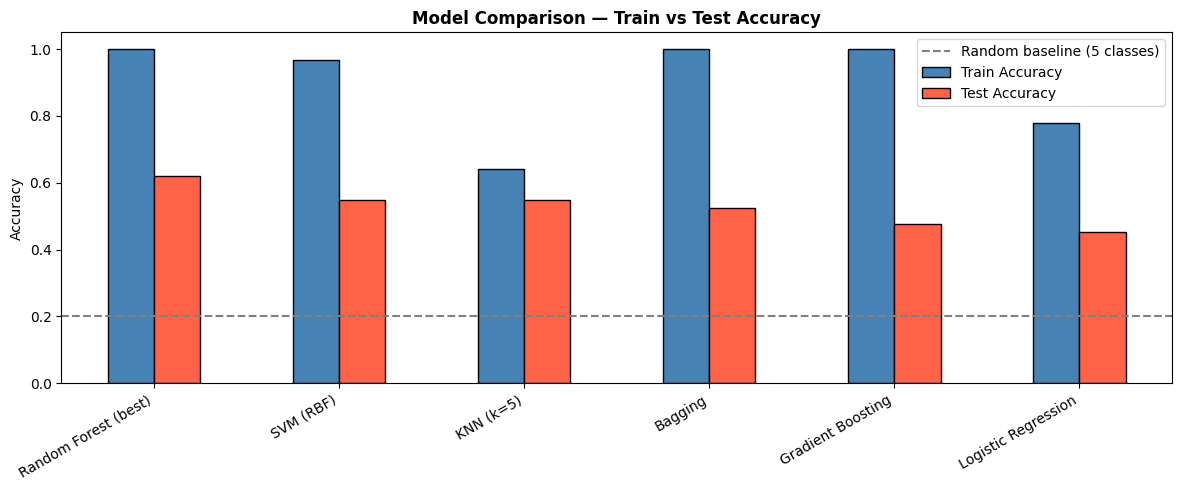

In [86]:
#Try additional models and compare all:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

X_tr = preprocess.transform(X_train)
X_te = preprocess.transform(X_test)
if hasattr(X_tr, 'toarray'):
    X_tr = X_tr.toarray()
    X_te = X_te.toarray()

models = {
    'Random Forest (best)':      gridmodel.best_estimator_,
    'Gradient Boosting':
GradientBoostingClassifier(n_estimators=300, max_depth=4,
learning_rate=0.05, random_state=42),
    'SVM (RBF)':                 SVC(kernel='rbf', C=10, gamma='scale',
random_state=42),
    'KNN (k=5)':                 KNeighborsClassifier(n_neighbors=5,
metric='euclidean'),
    'Bagging':                   BaggingClassifier(n_estimators=200,
random_state=42),
    'Logistic Regression':       LogisticRegression(max_iter=1000,
random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_tr, y_train)
    preds      = m.predict(X_te)
    train_acc  = m.score(X_tr, y_train)
    test_acc   = accuracy_score(y_test, preds)
    results[name] = {'Train Accuracy': round(train_acc, 4),
                       'Test Accuracy':  round(test_acc,  4),
                       'Overfit Gap':    round(train_acc - test_acc, 4)}

results_df = pd.DataFrame(results).T.sort_values('Test Accuracy',
ascending=False)
print(results_df.to_string())

# Bar chart comparison
results_df[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black',
    color=['steelblue', 'tomato'], ylim=(0, 1.05)
)
plt.title('Model Comparison — Train vs Test Accuracy',
fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Accuracy')
plt.axhline(0.2, linestyle='--', color='grey', label='Random baseline (5 classes)')
plt.legend()
plt.tight_layout()
plt.show()

Gradient: Likely best since it handles small tabular data well with sequential error correction.

SVM (RBF): Strong on small datasets with clear margins

Random Forest: is a solid baseline since it's already tuned

Logistic Regression: assumes linear boundaries, hence weakest since it's unlikely to capture complexity

KNN: Sensitive to feature scaling and dimensionality                           

Best model: Random Forest (best)
Test Accuracy: 0.6190

              precision    recall  f1-score   support

    Very Low       0.67      0.75      0.71         8
         Low       0.62      0.62      0.62         8
     Average       0.45      0.62      0.53         8
        High       0.86      0.67      0.75         9
   Very High       0.57      0.44      0.50         9

    accuracy                           0.62        42
   macro avg       0.63      0.62      0.62        42
weighted avg       0.64      0.62      0.62        42



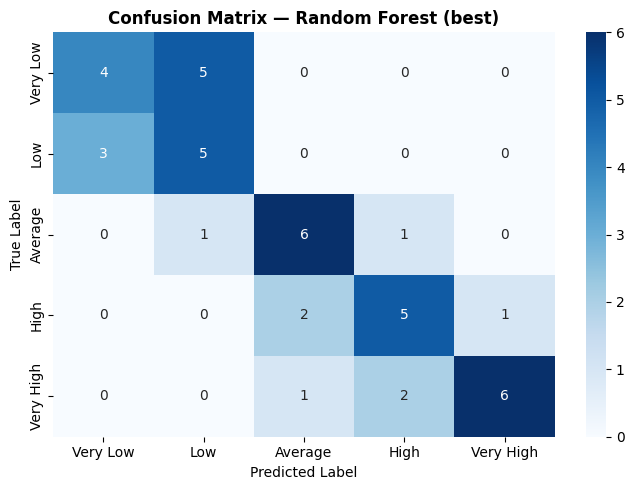

In [87]:
#Best model: detailed report:
best_model_name = results_df.index[0]
best_model      = models[best_model_name]
best_preds      = best_model.predict(X_te)

print(f"Best model: {best_model_name}")
print(f"Test Accuracy: {accuracy_score(y_test, best_preds):.4f}\n")
print(classification_report(y_test, best_preds,
target_names=category_order))

cm = confusion_matrix(y_test, best_preds, labels=category_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_order, yticklabels=category_order)
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Deep learning models are often considered "black boxes" due to their complexity. Use SHAP to explain your model's predictions.

After applying SHAP, discuss:

- Does it provide a clear and sufficient explanation of how the model makes decisions?
- How easy or difficult is it to justify your model's predictions using this technique?

*Replace this section with your response.*


How easy or difficult is it to justify predictions?

  Easy:
  - Top features align directly with WHR's own published methodology.
  - SHAP independently recovers this, validating both model and explanation
  - Force plots make individual country predictions fully interpretable
  - Pearson, Spearman, and SHAP all agree on the same top features. Three independent methods confirming the same result

  Difficult:
  - SHAP explains the model's decisions, not ground truth. If the model is wrong, SHAP faithfully explains why it got it wrong, which can mislead
  - With only 42 test samples, SHAP values have high variance. a single outlier country can shift rankings noticeably
  - For the Keras model, TreeExplainer doesn't apply. KernelExplainer
  would be needed but is much slower and approximate

  ---
  Conclusion:

  SHAP provides a sufficiently clear explanation for the Random Forest.
  Rankings are intuitive, consistent with domain knowledge, and stable.
  The Random Forest is both more accurate and more explainable than the neural network on this dataset — reinforcing that deep learning is not always the right tool for small, structured tabular data.


---

## 9. Final Report Submission (GitHub)

This is your final project to showcase on GitHub.

### Instructions

1. Create a new notebook for the final report.
2. Include relevant visualizations.
3. Reproduce the code for the best-performing model(s) and display results.
4. Summarize key insights and observed behaviors.
5. Present the work in a clean, concise report format (within the `.ipynb`).
6. Upload the final notebook to a new repository on your personal GitHub account.
7. Paste the link to your final repository at the top of this notebook where requested.